<h1>Analysis of Angular-Differential Post-Processing Algorithms for Exoplanet Direct Detection with a Photonic Lantern Nuller </h1>

<h3> Suvinay Goyal, Yinzi Xin, Nemanja Jovanovic, Dimitri Mawet, Michael P. Fitzgerald </h3>

This notebook gives the documented Python code to reproduce all the images in the paper "Analysis of Angular-Differential Post-Processing Algorithms for Exoplanet Direct Detection with a Photonic Lantern Nuller" published in JATIS.

## Execution note

 Some simulation and localization products are computationally expensive to regenerate, so the Zenodo archive includes precomputed intermediate `.npy`/data files used by the plotting and analysis cells.

The notebook should run top-to-bottom when the archived data files are present in the expected directory structure. Execution counts may not be sequential because the notebook was developed iteratively and some expensive intermediate-generation cells were replaced by loading archived data products.

<h4>Imports</h4>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate as rot
from scipy.interpolate import CubicSpline
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from hcipy import *
from matplotlib import colors
import warnings

warnings.filterwarnings('ignore')

<h4>Loading Simulated Data

The simulated data for the Coronagraphs and the PLN is provided in the data folder on the Zenodo release of this repository. Look at the `README.md` file for more details.

In [ ]:
#Demo simulated coronagraphic data (Simulated as a Charge 2)

coron_psfs = np.load("data/coron/coron_psfs.npy")
coron_seps = np.load("data/coron/coron_rs.npy")
coron_psfs_star = np.load("data/coron/coron_psf_star_ab.npy")
coron_psfs.shape, coron_seps.shape

((48, 660, 660), (48,))

In [135]:
# Simulated PLN PSFs from 0 to 2*pi to characterize inter-angular PSF correlations using normalized inner products on a 2D Grid

pln_psfs = np.load("data/pln/pln_psfs.npy")
pln_seps = np.load("data/pln/pln_rs.npy")
pln_thetas = np.load("data/pln/pln_thetas.npy")
pln_psfs.shape, pln_seps.shape, pln_thetas.shape

((13, 24, 6), (13,), (24,))

In [132]:
# Simulated PLN PSFs with limited sky coverage (10 degrees to 35 degrees) with 20 equally spaced frames, used to characterize self subtraction vs coronagraphs in the same angular range

pln_psfs_adi = np.load("data/pln/pln_psfs_adi.npy")
pln_psfs_star_errs = np.load("data/pln/pln_psf_star_ab_cube.npy")
pln_seps_adi = np.load("data/pln/pln_rs_adi.npy")
pln_thetas_adi = np.load("data/pln/pln_thetas_adi.npy")
pln_psfs_adi.shape, pln_psfs_star_errs.shape,  pln_seps_adi.shape, pln_thetas_adi.shape

((5, 20, 6), (20, 6), (5,), (20,))

In [134]:
#Simulated Vortex Coronagraphic PSFs with different charges

coron_psfs_c6 = np.load("data/coron/coron_psfs_c6.npy")
coron_psfs_c4 = np.load("data/coron/coron_psfs_c4.npy")
coron_psfs_c2 = np.load("data/coron/coron_psfs_c2.npy")
coron_psfs_star_c2 = np.load("data/coron/coron_psf_star_ab_cube_c2.npy")
coron_psfs_star_c4 = np.load("data/coron/coron_psf_star_ab_cube_c4.npy")
coron_psfs_star_c6 = np.load("data/coron/coron_psf_star_ab_cube_c6.npy")

In [21]:
#simulated PLN Stellar Aberrations with higher angular coverage (upto 400 degrees) with each frame spaced apart by 1.25 degrees. Subindexing them yields stellar signals with 25, 150 and 100 degrees respectively.

pln_psfs_star_mc_ez= np.load("data/pln/many_pln_star_ab_high_correlation_wide_angle.npy")[:,0:20,:]
pln_psfs_star_errs_wide_mc_ez = np.load("data/pln/many_pln_star_ab_high_correlation_wide_angle.npy")[:,0:120,:] #'wide' in this file generally corresponds to datasets with 150 degrees angular coverage
pln_psfs_star_errs_100_mc_ez = np.load("data/pln/many_pln_star_ab_high_correlation_wide_angle.npy")[:,0:80,:]

<h4> PLN Companion Signal Data generation Code using HCIPy

In [104]:
#setup for PLN
grid_size = 200
pupil_grid = make_pupil_grid(grid_size)
focal_grid = make_focal_grid_from_pupil_grid(pupil_grid,11,3)
prop = FraunhoferPropagator(pupil_grid, focal_grid)
dx = focal_grid.x[1]-focal_grid.x[0]
dxi = pupil_grid.x[1]-pupil_grid.x[0]

circ = circular_aperture(diameter=1)
aperture = circ(pupil_grid)
lp_modes_c0 = make_LP_modes(focal_grid,1.5*np.pi,1.4) 
num_modes = len(lp_modes_c0)
def prop_6p_vfn_c0(wfe=None,tt_x=0,tt_y=0,dm1_acts=None,dm2_acts=None):
    #if wfe
    if wfe is not None:
        wf = Wavefront(aperture*np.exp(1j*wfe)*np.exp(1j*2*np.pi*(tt_x)*pupil_grid.x)*np.exp(1j*2*np.pi*(tt_y)*pupil_grid.y))
    else:
        wf = Wavefront(aperture*np.exp(1j*2*np.pi*(tt_x)*pupil_grid.x)*np.exp(1j*2*np.pi*(tt_y)*pupil_grid.y))

    #if DM 1
    if dm1_acts is not None:
        dm1 = DeformableMirror(influence_functions)
        dm1.actuators = dm1_acts
        wf = dm1(wf)

    foc_c0 = prop.forward(wf)
    output = np.zeros(len(lp_modes_c0))
    for k in range(len(lp_modes_c0)):
        overlap_integrand_c0 = lp_modes_c0[k].astype('complex128')*foc_c0.electric_field*dx**2
        tot_intensity_c0 = np.sum(np.square(np.abs(wf.electric_field)),axis=None)*dxi**2
        output[k] = np.square(np.abs(np.sum(overlap_integrand_c0)))/tot_intensity_c0
    return output


#Function used to generate PLN companion with 25 degrees of sky coverage
def pln_psfs_generation(r_hat, theta_hat,FR_hat = None):
    grid_size = 200
    pupil_grid = make_pupil_grid(grid_size)
    focal_grid = make_focal_grid_from_pupil_grid(pupil_grid,11,3)
    prop = FraunhoferPropagator(pupil_grid, focal_grid)
    dx = focal_grid.x[1]-focal_grid.x[0]
    dxi = pupil_grid.x[1]-pupil_grid.x[0]

    circ = circular_aperture(diameter=1)
    aperture = circ(pupil_grid)
    lp_modes_c0 = make_LP_modes(focal_grid,1.5*np.pi,1.4)  
    num_modes = len(lp_modes_c0)
    thetas_hat = np.linspace(theta_hat, (theta_hat + (5*np.pi)/36), 20, endpoint=True)
    pln_psfs_hat = np.zeros((len(thetas_hat), num_modes))
    for hat,t_hat in enumerate(thetas_hat):
        xk = r_hat*np.cos(t_hat)
        yk = r_hat*np.sin(t_hat)
        if FR_hat:
            pln_psfs_hat[hat,:] = FR_hat*prop_6p_vfn_c0(wfe=None,tt_x=xk,tt_y=yk)
        else:
            pln_psfs_hat[hat,:] = prop_6p_vfn_c0(wfe=None,tt_x=xk,tt_y=yk)
        
    return pln_psfs_hat

#Function used to generate PLN companion with 150 degrees of sky coverage
def pln_psfs_generation_wider(r_hat, theta_hat,FR_hat = None):
    grid_size = 200
    pupil_grid = make_pupil_grid(grid_size)
    focal_grid = make_focal_grid_from_pupil_grid(pupil_grid,11,3)
    prop = FraunhoferPropagator(pupil_grid, focal_grid)
    dx = focal_grid.x[1]-focal_grid.x[0]
    dxi = pupil_grid.x[1]-pupil_grid.x[0]

    circ = circular_aperture(diameter=1)
    aperture = circ(pupil_grid)
    lp_modes_c0 = make_LP_modes(focal_grid,1.5*np.pi,1.4)  
    num_modes = len(lp_modes_c0)
    thetas_hat = np.linspace(theta_hat, (theta_hat + (5*np.pi)/6), 120, endpoint=True)
    pln_psfs_hat = np.zeros((len(thetas_hat), num_modes))
    for hat,t_hat in enumerate(thetas_hat):
        xk = r_hat*np.cos(t_hat)
        yk = r_hat*np.sin(t_hat)
        if FR_hat:
            pln_psfs_hat[hat,:] = FR_hat*prop_6p_vfn_c0(wfe=None,tt_x=xk,tt_y=yk)
        else:
            pln_psfs_hat[hat,:] = prop_6p_vfn_c0(wfe=None,tt_x=xk,tt_y=yk)        
    return pln_psfs_hat

#Function used to generate PLN companion with 100 degrees of sky coverage
def pln_psfs_generation_100(r_hat, theta_hat,FR_hat = None):
    grid_size = 200
    pupil_grid = make_pupil_grid(grid_size)
    focal_grid = make_focal_grid_from_pupil_grid(pupil_grid,11,3)
    prop = FraunhoferPropagator(pupil_grid, focal_grid)
    dx = focal_grid.x[1]-focal_grid.x[0]
    dxi = pupil_grid.x[1]-pupil_grid.x[0]

    circ = circular_aperture(diameter=1)
    aperture = circ(pupil_grid)
    lp_modes_c0 = make_LP_modes(focal_grid,1.5*np.pi,1.4)  #lp_modes wasn't defined elsewhere, I would assume that the variable was misnamed or etc
    num_modes = len(lp_modes_c0)
    thetas_hat = np.linspace(theta_hat, (theta_hat + (5*np.pi)/9), 80, endpoint=True)
    pln_psfs_hat = np.zeros((len(thetas_hat), num_modes))
    for hat,t_hat in enumerate(thetas_hat):
        xk = r_hat*np.cos(t_hat)
        yk = r_hat*np.sin(t_hat)
        if FR_hat:
            pln_psfs_hat[hat,:] = FR_hat*prop_6p_vfn_c0(wfe=None,tt_x=xk,tt_y=yk)
        else:
            pln_psfs_hat[hat,:] = prop_6p_vfn_c0(wfe=None,tt_x=xk,tt_y=yk)        
    return pln_psfs_hat

<h4> Section 2 : Background</h4>

In [20]:
def pln_dot_product(pln_data, separations, thetas, sep, theta1, theta2, degree = True):
    #Calculates normalized correlation between two PLN Frames at a given separation and two angles. The angles can be in degrees or radians, depending on the degree argument.
    thetas_data = pln_data[np.where(separations==sep)[0][0]]
    interp = CubicSpline(thetas, thetas_data)
    if degree:
        angle_rad_1 = np.deg2rad(theta1)
        angle_rad_2 = np.deg2rad(theta2)
        psf1 = interp(angle_rad_1)
        psf2 = interp(angle_rad_2)
        
    else:
        psf1 = interp(theta1)
        psf2 = interp(theta2)
    psf1_normed = psf1/np.linalg.norm(psf1)
    psf2_normed = psf2/np.linalg.norm(psf2)
    return psf1_normed.T @ psf2_normed


def coron_dot_product(coron_data, separations, sep, theta1, theta2, degree = True):
    #Calculates normalized correlation between two Coronagraph frames at a given separation and two angles. The angles can be in degrees or radians, depending on the degree argument.
    psf =coron_data[np.where(separations==sep)[0][0]]
    if degree == False:
        angle_deg_1 = np.rad2deg(theta1)
        angle_deg_2 = np.rad2deg(theta2)
        psf_1 = rot(psf, angle_deg_1, reshape = False)
        psf_2 = rot(psf, angle_deg_2, reshape = False)
        psf_1d_1 = psf_1.ravel()
        psf_1d_2 = psf_2.ravel()
    else:
        angle_rad_1 = np.deg2rad(theta1)
        angle_rad_2 = np.deg2rad(theta2)
        psf_1 = rot(psf, theta1, reshape = False)
        psf_2 = rot(psf, theta2, reshape = False)
        psf_1d_1 = psf_1.ravel()
        psf_1d_2 = psf_2.ravel()
    psf1_normed = psf_1d_1/np.linalg.norm(psf_1d_1)
    psf2_normed = psf_1d_2/np.linalg.norm(psf_1d_2)
    return psf1_normed.T @ psf2_normed 

def fm_data_gen(coron_data, coron_star, rot_angles, sep_inds,  FR):
    #Function to generate self subctraction windows at planet positions for coronagraphic data with a given forward model flux ratio (FR). 
    #The function returns the combined data, the planet data, the planet windows and the pre-forward model RMS values.
    fm_data_combined = np.zeros((len(sep_inds), len(rot_angles), coron_data.shape[1], coron_data.shape[2]))
    fm_data_planet = np.zeros((20, 20, 660, 660))
    planet_windows_fm = np.zeros(fm_data_combined.shape)
    pre_fm_rms = np.zeros((len(sep_inds),len(rot_angles)))
    for i, ind in enumerate(sep_inds):
        for j, angle in enumerate(rot_angles):
            new_psf = rot(coron_data[ind], angle, reshape = False)
            planet_center_y, planet_center_x = np.unravel_index(np.argmax(new_psf), new_psf.shape)
            y, x = np.ogrid[:660, :660]
            distance_from_center = np.sqrt((x - planet_center_x)**2 + (y - planet_center_y)**2)
            mask = distance_from_center<42
            planet_windows_fm[i,j] = mask
            fm_data_planet[i, j] = FR*new_psf
            fm_data_combined[i, j] = coron_star[j] + FR*new_psf
            pre_fm_rms[i,j] = np.sqrt(np.mean(fm_data_planet[i, j][mask]**2))
    return(fm_data_combined, fm_data_planet, planet_windows_fm, pre_fm_rms)

def forward_model(combined_psf, planet_psf):
    #Function to forward  model given science data and planet data. The function returns the forward model result.
    model_result = np.zeros_like(planet_psf)
    for i in range (0,planet_psf.shape[0]):
        for j in range(0, planet_psf.shape[1]):
            median_arr = np.delete(combined_psf[i],j , axis = 0)
            median = np.median(median_arr, axis = 0)
            model_result[i,j] = planet_psf[i,j]-median
    return model_result

def post_fm_I_rms(fm_result, planet_windows):
    #Function to calculate the remaining planet rms intensity in the window post forward model.
    post_fm_rms = np.zeros((fm_result.shape[0],fm_result.shape[1]))
    for i in range(0, fm_result.shape[0]):
        for j in range(0, fm_result.shape[1]):
            mask = planet_windows[i,j].astype(bool)
            post_fm_rms[i,j] = np.sqrt(np.mean(fm_result[i, j][mask]**2))
    return(post_fm_rms)

def pre_post_ratio(post_fm_rms, pre_fm_rms):
    #Function to calculate the ratio of post forward model rms to pre forward model rms. 
    rms_ratio = np.mean(post_fm_rms/pre_fm_rms, axis = 1)
    return (rms_ratio)


<h4> 2.1 Photonic Lantern Nuller </h4>

Fig  2

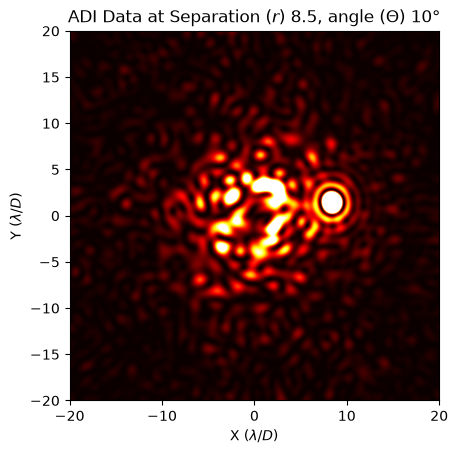

In [141]:
#This code calculates the coronagraphic frames for companion's ADI motion across the sky and the for different companions at varying angular separations. 
#For the paper it is only used the plot the first frame at 10 degrees, but can be used to generate an animation. 
coron_seps_adi_far = np.arange(8.5,11, 0.5)
rot_excl_angles = np.rad2deg(np.linspace(np.pi/18, (7*np.pi)/36, 20, endpoint=True)) #  exclusion angles defined
sep_inds_far = [np.where(coron_seps == x)[0][0] for x in coron_seps_adi_far]
adi_data_cl_wstar = np.zeros((5, 20, 660, 660))
adi_data_far_wstar = np.zeros((5, 20, 660, 660))
FR = 1e-5
for i, ind in enumerate(sep_inds_far):
    for j, angle in enumerate(rot_excl_angles):
        new_psf = rot(coron_psfs[ind], angle, reshape = False)
        adi_data_far_wstar[i, j] = coron_psfs_star + FR*new_psf


dpix = 0.06060606060606233 #Amount of angular separations covered per pixel in a 660x660 pixel image.
fig, ax = plt.subplots()
image = ax.imshow(adi_data_far_wstar[0, 0], cmap='hot', extent = [-330*dpix,330*dpix, -330*dpix, 330*dpix], 
                  vmin = np.min(adi_data_far_wstar), vmax = np.percentile(adi_data_far_wstar, 99))
ax.set_xlim(-330*dpix,330*dpix)
ax.set_ylim(-330*dpix,330*dpix)
ax.set_title(rf"ADI Data at Separation ($r$) {coron_seps_adi_far[0]}, angle ($\Theta$)"+ f" {int(rot_excl_angles[0])}\u00b0") 
ax.set_xlabel(r"X ($\lambda/D$)")
ax.set_ylabel(r"Y ($\lambda/D$)")
plt.show()

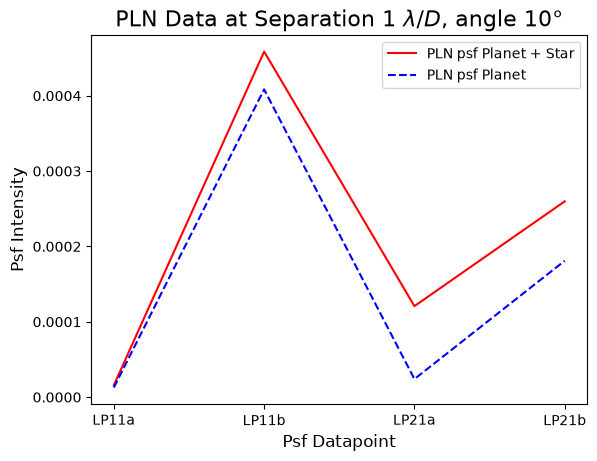

In [142]:
#This code calculates the PLN frames for companion's ADI motion across the sky and the for different companions at varying angular separations. 
#For the paper it is only used the plot the first frame at 10 degrees, but can be used to generate an animation. 


adi_data_pln_wstar_diffs = np.zeros((5, 20, 6))
FR_pln = 1e-3
for i in range (len(pln_seps_adi)):
        for j in range(len(pln_thetas_adi)):
                adi_data_pln_wstar_diffs[i, j] = pln_psfs_star_errs[j] + FR_pln*pln_psfs_adi[i,j]

fig, ax = plt.subplots()
ax.plot(np.arange(2,6), adi_data_pln_wstar_diffs[1, 0, 1:5], label = "PLN psf Planet + Star", c = "r")
ax.plot(np.arange(2,6), 1e-3*pln_psfs_adi[1, 0, 1:5], label = "PLN psf Planet", c= "b", ls = "--")
ax.set_xticks([2, 3, 4, 5])  
ax.set_xticklabels(["LP11a", "LP11b", "LP21a", "LP21b"])  
ax.set_xlabel("Psf Datapoint", fontsize = 12)
ax.set_ylabel("Psf Intensity", fontsize = 12)
ax.set_title(f"PLN Data at Separation 1 $\lambda/D$, angle 10\u00b0", fontsize = 16)
ax.legend()
plt.show()

<h4> 2.2 Comparative Problems </h4>

Fig 3

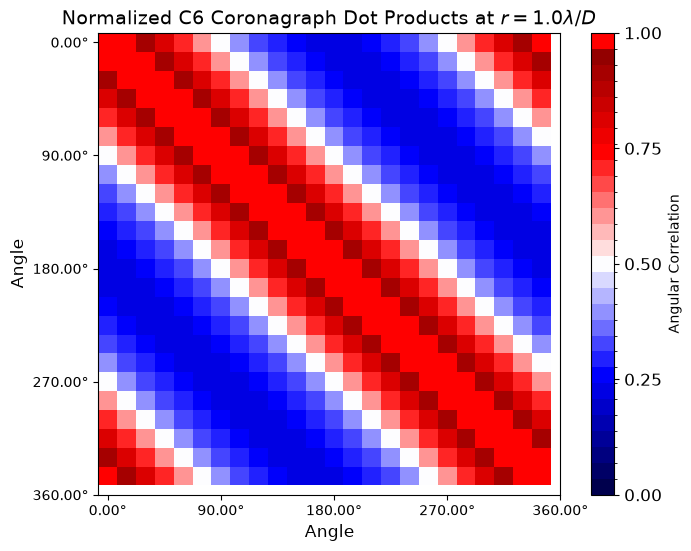

In [ ]:
#Code used to generate the normalized dot product matrix for Coronagraph frames from 0 to 2pi at given separations (1 lambda/D and 7 lambda/D). 
#The matrix is then plotted as a heatmap to visualize the angular correlation between different coronagraphic frames.

coron_thetas = np.arange(0,np.pi*2,np.pi/12)
coron_dot_matrix_1 = np.zeros((len(coron_thetas), len(coron_thetas)))
coron_dot_matrix_7 = np.zeros((len(coron_thetas), len(coron_thetas)))
for j, th1 in enumerate(coron_thetas):
    for k, th2 in enumerate(coron_thetas):
        coron_dot_matrix_1[j,k] = coron_dot_product(coron_psfs, coron_seps, 1, th1, th2, degree = False)
        coron_dot_matrix_7[j,k] = coron_dot_product(coron_psfs, coron_seps, 7, th1, th2, degree = False)


cmap = plt.cm.seismic
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[-1]='red' 
cmap = colors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)
norm = colors.BoundaryNorm(list(np.linspace(0, 1, 30)), cmap.N)
fig, ax = plt.subplots(figsize = (8,6))
plt.grid(False)
img = ax.imshow(coron_dot_matrix_1, cmap=cmap, norm=norm, animated=True)
cbar = plt.colorbar(img, label = "Angular Correlation", cmap = "seismic")
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])  
cbar.ax.tick_params(labelsize=12)
x_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
y_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
ax.set_xticks(np.arange(len(x_values))[::6])
ax.set_yticks(np.arange(len(y_values))[::6])
ax.set_xticklabels([f'{val:.2f}\u00b0' for val in x_values][::6], fontsize = 10)
ax.set_yticklabels([f'{val:.2f}\u00b0' for val in y_values][::6], fontsize = 10)
ax.set_xlabel("Angle", fontsize = 12)
ax.set_ylabel("Angle", fontsize = 12)
ax.set_title(r'Normalized C6 Coronagraph Dot Products at $r = 1.0 \lambda/D$', fontsize = 14)
plt.show()

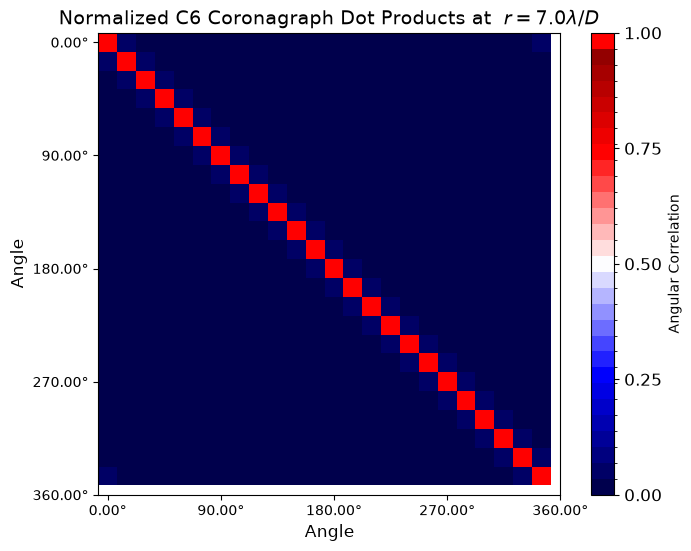

In [144]:
#This code plots matrix at 7 lambda/D as a heatmap to visualize the angular correlation between different coronagraphic frames at this separation.

cmap = plt.cm.seismic
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[-1]='red' 
cmap = colors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)
norm = colors.BoundaryNorm(list(np.linspace(0, 1, 30)), cmap.N)
fig, ax = plt.subplots(figsize = (8,6))
plt.grid(False)
img = ax.imshow(coron_dot_matrix_7, cmap=cmap, norm=norm, animated=True)
cbar = plt.colorbar(img, label = "Angular Correlation", cmap = "seismic")
cbar.ax.tick_params(labelsize=12)  
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])  
x_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
y_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
ax.set_xticks(np.arange(len(x_values))[::6])
ax.set_yticks(np.arange(len(y_values))[::6])
ax.set_xticklabels([f'{val:.2f}\u00b0' for val in x_values][::6], fontsize = 10)
ax.set_yticklabels([f'{val:.2f}\u00b0' for val in y_values][::6], fontsize = 10)
ax.set_xlabel("Angle", fontsize = 12)
ax.set_ylabel("Angle", fontsize = 12)
ax.set_title(r'Normalized C6 Coronagraph Dot Products at  $r = 7.0 \lambda/D$', fontsize = 14)
plt.show()

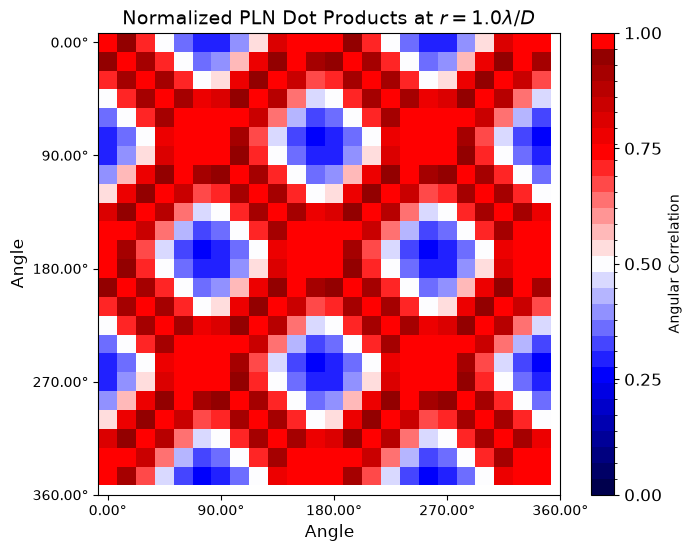

In [143]:
#Code used to generate the normalized dot product matrix for PLN frames from 0 to 2pi at a given separation (1 lambda/D). 
#The matrix is then plotted as a heatmap to visualize the angular correlation between different PLN frames.

pln_dot_matrix_1 = np.zeros((len(pln_thetas), len(pln_thetas)))
for j, th1 in enumerate(pln_thetas):
        for k, th2 in enumerate(pln_thetas):
            pln_dot_matrix_1[j,k] = pln_dot_product(pln_psfs, pln_seps, pln_thetas, 1, th1, th2, degree = False)

cmap = plt.cm.seismic
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[-1]='red' 
cmap = colors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)
norm = colors.BoundaryNorm(list(np.linspace(0, 1, 30)), cmap.N)
fig, ax = plt.subplots(figsize = (8,6))
plt.grid(False)
img = ax.imshow(pln_dot_matrix_1, cmap=cmap, norm=norm, animated=True)
cbar = plt.colorbar(img, label = "Angular Correlation", cmap = "seismic")
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])  
cbar.ax.tick_params(labelsize=12)
x_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
y_values = np.linspace(0, 2 * np.pi, 25)*180/np.pi
ax.set_xticks(np.arange(len(x_values))[::6])
ax.set_yticks(np.arange(len(y_values))[::6])
ax.set_xticklabels([f'{val:.2f}\u00b0' for val in x_values][::6], fontsize = 10)
ax.set_yticklabels([f'{val:.2f}\u00b0' for val in y_values][::6], fontsize = 10)
ax.set_xlabel("Angle", fontsize = 12)
ax.set_ylabel("Angle", fontsize = 12)
ax.set_title(r'Normalized PLN Dot Products at $r = 1.0 \lambda/D$', fontsize = 14)
plt.show()

Fig 4

In [14]:
#This code generates the forward model for PLN frames with 25 degrees of sky coverage. The forward model is calculated for a given flux ratio (FR = 0.01) and the resulting data is stored in pln_adi_fm_result.

coron_seps_fm = np.arange(0.5, 10.5, 0.5)
sep_inds = [np.where(coron_seps == x)[0][0] for x in coron_seps_fm] 
planet_data_pln_fm = np.zeros((5, 20, 6))
FR_pln = 0.01
for i in range (len(pln_seps_adi)):
        for j in range(len(pln_thetas_adi)):
                planet_data_pln_fm[i, j] = FR_pln*pln_psfs_adi[i,j]
pln_adi_fm_result = forward_model(planet_data_pln_fm, planet_data_pln_fm)

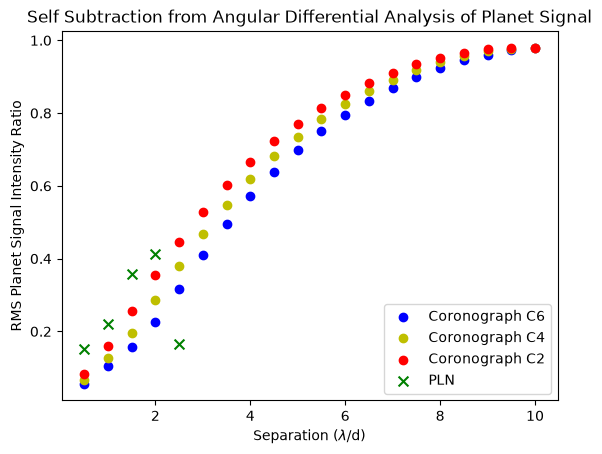

In [15]:
# This code generates the forward model for coronagraphic frames with different charges (C2, C4, C6) and a given flux ratio (FR = 0.01). 
# The pre and post forward model RMS values are calculated and the ratio of post to pre RMS values is computed for each coronagraphic charge. 
# The planet windows for the PLN data are taken to be all the nulled ports compared with the 42 pixel radius planet window defined for the coronagraphic data taken to encompass most of the planet signal. 

fm_data_combined_c6, fm_data_planet_c6, planet_windows_fm_c6, pre_fm_rms_c6 = fm_data_gen(coron_psfs_c6, coron_psfs_star_c6, rot_excl_angles, sep_inds, 1e-2)
fm_data_combined_c4, fm_data_planet_c4, planet_windows_fm_c4, pre_fm_rms_c4 = fm_data_gen(coron_psfs_c4, coron_psfs_star_c4, rot_excl_angles, sep_inds, 1e-2)
fm_data_combined_c2, fm_data_planet_c2, planet_windows_fm_c2, pre_fm_rms_c2 = fm_data_gen(coron_psfs_c2, coron_psfs_star_c2, rot_excl_angles, sep_inds, 1e-2)
fm_result_c6 = forward_model(fm_data_planet_c6, fm_data_planet_c6)
fm_result_c4 = forward_model(fm_data_planet_c4, fm_data_planet_c4)
fm_result_c2 = forward_model(fm_data_planet_c2, fm_data_planet_c2)
post_fm_I_rms_c6 = post_fm_I_rms(fm_result_c6, planet_windows_fm_c6)
post_fm_I_rms_c4 = post_fm_I_rms(fm_result_c4, planet_windows_fm_c4)
post_fm_I_rms_c2 = post_fm_I_rms(fm_result_c2, planet_windows_fm_c2)
rms_ratio_c6 = pre_post_ratio(post_fm_I_rms_c6, pre_fm_rms_c6)
rms_ratio_c4 = pre_post_ratio(post_fm_I_rms_c4, pre_fm_rms_c4)
rms_ratio_c2 = pre_post_ratio(post_fm_I_rms_c2, pre_fm_rms_c2)
pre_fm_pln_rms = np.zeros((5,20))
post_fm_pln_rms = np.zeros((5,20))
for i in range(0, planet_data_pln_fm.shape[0]):
    for j in range(0, planet_data_pln_fm.shape[1]):
        pre_fm_pln_rms[i,j] = np.sqrt(np.mean(planet_data_pln_fm[i,j,1:5]**2))
        post_fm_pln_rms[i,j] = np.sqrt(np.mean(pln_adi_fm_result[i,j,1:5]**2))
adi_rms_ps_fm_pln_inv = np.mean(post_fm_pln_rms/pre_fm_pln_rms, axis = 1)


plt.scatter(coron_seps_fm, rms_ratio_c6, label = "Coronograph C6", c= "b")
plt.scatter(coron_seps_fm, rms_ratio_c4, label = "Coronograph C4", c= "y")
plt.scatter(coron_seps_fm, rms_ratio_c2, label = "Coronograph C2", c= "r")
plt.scatter(pln_seps_adi, adi_rms_ps_fm_pln_inv, label = "PLN", c= "g", marker = "x", s = 50)
plt.legend(loc = "lower right")
plt.xlabel(r"Separation ($\lambda$/d)", fontsize = 10)
plt.ylabel("RMS Planet Signal Intensity Ratio", fontsize = 10)
plt.title("Self Subtraction from Angular Differential Analysis of Planet Signal", fontsize = 12)
plt.show()

<h4> Section 4 : Statistical Comparison

In [150]:
def direct_fit_detection(planet_hat, actual_psf, return_ests = False):
    #Direct fit cost function used in detection testing. return_ests is used as a debugging parameter returning relevant arrays besides the cost.
    if return_ests:
        return ((actual_psf-planet_hat)**2).mean(), (actual_psf-planet_hat), actual_psf-planet_hat, planet_hat, actual_psf-planet_hat, actual_psf- (actual_psf-planet_hat)
    else:
        return ((actual_psf-planet_hat)**2).mean()
    
def forward_model_klip(planet_psfs, stellar_components):
    # Forward model function used for klip cost function in detection testing
    fwms = []
    for frame in range(0, planet_psfs.shape[0]):
        fwms.append(planet_psfs[frame]-stellar_components[frame].T.dot(stellar_components[frame].dot(planet_psfs[frame])))
    return np.array(fwms)

def klip_detection(planet_hat, actual_psf, n_comp,  return_ests = False, processing = False, frame = None):
    # KLIP cost function used in detection testing. return_ests is used as a debugging parameter returning relevant arrays besides the cost. 
    I_star_hat = np.zeros_like(actual_psf)
    if processing:
        init_planet_frame = planet_hat[frame]
        init_star_frame = actual_psf[frame]
    N = actual_psf.shape[0]
    all_comps = np.zeros((N, n_comp, actual_psf.shape[1]))
    for ang in range (0,N):
        reference_psfs = np.delete(actual_psf, ang, axis=0)
        target_psf = actual_psf[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]
        all_comps[ang] = components  
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
        if processing:
            if ang == frame:
                star_frame_after_reduction = I_star_hat[frame]
    if return_ests:
        if processing:
            forward_model_planet_frame = forward_model_klip(planet_hat, all_comps)[frame]
            return (((actual_psf-I_star_hat - forward_model_klip(planet_hat, all_comps)))**2).mean(), (((actual_psf - forward_model_klip(planet_hat, all_comps)))), I_star_hat, forward_model_klip(planet_hat, all_comps), (actual_psf-I_star_hat - forward_model_klip(planet_hat, all_comps)), actual_psf-I_star_hat, init_planet_frame, init_star_frame, forward_model_planet_frame, star_frame_after_reduction 
        else:  
            return (((actual_psf-I_star_hat - forward_model_klip(planet_hat, all_comps)))**2).mean(), (((actual_psf - forward_model_klip(planet_hat, all_comps)))), I_star_hat, forward_model_klip(planet_hat, all_comps), (actual_psf-I_star_hat - forward_model_klip(planet_hat, all_comps)), actual_psf-I_star_hat
    
    else:
        return (((actual_psf-I_star_hat - forward_model_klip(planet_hat, all_comps)))**2).mean()
    
def main_klip_detection(planet_hat, actual_psf, n_comp, return_ests = False, processing = False, frame = None):
    # Antiplanet KLIP cost function used in detection testing. return_ests is used as a debugging parameter returning relevant arrays besides the cost. 
    I_stellars_hat = actual_psf - planet_hat
    I_star_hat = np.zeros_like(actual_psf)
    if processing:
        init_planet_frame = planet_hat[frame]
        init_star_frame = I_stellars_hat[frame]
    N = I_stellars_hat.shape[0]
    for ang in range (0,N):
        reference_psfs = np.delete(I_stellars_hat, ang, axis=0)
        target_psf = I_stellars_hat[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False)  
        components = Vt[:n_comp]  
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
        if processing:
            if ang == frame:
                star_frame_after_reduction = I_star_hat[frame]
    if return_ests:
        if processing:
            planet_frame = planet_hat[frame]
            return (((actual_psf-I_star_hat - planet_hat))**2).mean(), (((actual_psf - planet_hat))), I_star_hat, planet_hat, (actual_psf-I_star_hat - planet_hat), actual_psf- I_star_hat, init_planet_frame, init_star_frame, planet_frame, star_frame_after_reduction 
        else:
            return (((actual_psf-I_star_hat - planet_hat))**2).mean(), (((actual_psf - planet_hat))), I_star_hat, planet_hat, (actual_psf-I_star_hat - planet_hat), actual_psf- I_star_hat
    
    else:
        return (((actual_psf-I_star_hat - planet_hat))**2).mean()
    
def monte_carlo_klip(all_datasets,true_planet, det_sep, det_theta, det_fr, n_comp,  verbose = True, angle = 25):
    # Function to run monte carlo simulations for detection testing. The function returns the test parameter (-cost) values for each detection method (direct fit, KLIP, and main KLIP) for both H1 and H0 datasets. 
    # The angle parameter is used to specify the sky coverage angle for the PLN companion generation. The n_comp parameter specifies the n_comp for both KLIP and Antiplanet KLIP in this so that the same number of components can be compared at once. 
    # This can be changed to accept two different n_comp values for each cost function.

    
    if angle == 25:
        guess_planet = pln_psfs_generation(det_sep, det_theta, det_fr)[:,1:5]
    elif angle == 100:
        guess_planet = pln_psfs_generation_100(det_sep, det_theta, det_fr)[:,1:5]
    elif angle == 150:
        guess_planet = pln_psfs_generation_wider(det_sep, det_theta, det_fr)[:,1:5]
    
    direct_h1 = np.zeros(len(all_datasets))
    klip_h1 = np.zeros(len(all_datasets))
    main_klip_h1 = np.zeros(len(all_datasets))
    direct_h0 = np.zeros(len(all_datasets))
    klip_h0 = np.zeros(len(all_datasets))
    main_klip_h0 = np.zeros(len(all_datasets))
    for id, d in enumerate(all_datasets):
        h1_data = all_datasets[id][:,1:5] + true_planet
        res_direct_h1 = -direct_fit_detection(guess_planet,h1_data)
        res_klip_h1 = -klip_detection(guess_planet, h1_data, n_comp = n_comp)
        res_main_klip_h1 = -main_klip_detection(guess_planet, h1_data, n_comp = n_comp)
        res_direct_h0 = -direct_fit_detection(guess_planet,d[:,1:5])
        res_klip_h0 = -klip_detection(guess_planet, d[:,1:5], n_comp = n_comp)
        res_main_klip_h0 = -main_klip_detection(guess_planet, d[:,1:5], n_comp = n_comp)
        direct_h1[id] = res_direct_h1
        klip_h1[id] = res_klip_h1
        main_klip_h1[id] = res_main_klip_h1
        direct_h0[id] = res_direct_h0
        klip_h0[id] = res_klip_h0
        main_klip_h0[id] = res_main_klip_h0
        if verbose:
            if id%100 ==0:
                print(f"Now on Dataset : {id}")
    
    return (direct_h1, klip_h1, main_klip_h1, direct_h0, klip_h0, main_klip_h0)

def detection_plots_klip(direct_h1, klip_h1, main_klip_h1, direct_h0, klip_h0, main_klip_h0, n_comp, direct_bins = 400, main_klip_bins = 800, 
                         klip_bins = 800, fr = None, sky_coverage = 25, energy = False, true_params = None, test_params = None, method_lim = None, 
                         plot_all = False, xlim_right = 1.00, roc_legend = "lower right", roc_dir_alpha =  1, roc_main_alpha = 1, roc_klip_alpha = 1):
    # Function to plot the detection testing results for the three detection methods (direct fit, KLIP, and main KLIP). The function generates histograms of the cost values for both H1 and H0 datasets for each method. 
    # The function also calculates the minimum and maximum cost values for each method to determine the appropriate binning for the histograms. It then normalizes the number of cost values from H1 and H0 per bin to plot the ROC curves.
    max_direct_h0 = np.max(direct_h0)
    min_direct_h1 = np.min(direct_h1)
    min_direct_h0 = np.min(direct_h0)
    max_direct_h1 = np.max(direct_h1)
    min_direct = np.min(np.hstack((direct_h1,direct_h0)))
    max_direct = np.max(np.hstack((direct_h1,direct_h0)))
    max_klip_h0 = np.max(klip_h0)
    min_klip_h1 = np.min(klip_h1)
    min_klip_h0 = np.min(klip_h0)
    max_klip_h1 = np.max(klip_h1)
    min_klip = np.min(np.hstack((klip_h1,klip_h0)))
    max_klip = np.max(np.hstack((klip_h1,klip_h0)))
    max_main_klip_h0 = np.max(main_klip_h0)
    min_main_klip_h1 = np.min(main_klip_h1)
    min_main_klip_h0 = np.min(main_klip_h0)
    max_main_klip_h1 = np.max(main_klip_h1)
    min_main_klip = np.min(np.hstack((main_klip_h1,main_klip_h0)))
    max_main_klip = np.max(np.hstack((main_klip_h1,main_klip_h0)))
    if (min_direct_h1>max_direct_h0) or (min_direct_h0>max_direct_h1):
        bins_direct = np.linspace(min_direct,max_direct,direct_bins)
    elif min_direct_h1 < max_direct_h0:
        bins_direct = np.array([min_direct]+list(np.linspace(min_direct_h0,max_direct_h1,direct_bins)) + [max_direct])
    else:
        bins_direct = np.array([min_direct]+list(np.linspace(min_direct_h1,max_direct_h0,direct_bins)) + [max_direct])
    if (min_klip_h1>max_klip_h0) or (min_klip_h0>max_klip_h1):
        bins_klip = np.linspace(min_klip,max_klip,klip_bins)
    elif min_klip_h1 < max_klip_h0:
        bins_klip = np.array([min_klip]+list(np.linspace(min_klip_h0,max_klip_h1,klip_bins)) + [max_klip])
    else:
        bins_klip = np.array([min_klip]+list(np.linspace(min_klip_h1,max_klip_h0,klip_bins)) + [max_klip])
    if (min_main_klip_h1>max_main_klip_h0) or (min_main_klip_h0>max_main_klip_h1):
        bins_main_klip = np.linspace(min_main_klip,max_main_klip,main_klip_bins)
    elif min_main_klip_h1 < max_main_klip_h0:
        bins_main_klip = np.array([min_main_klip] + list(np.linspace(min_main_klip_h0,max_main_klip_h1,main_klip_bins)) + [max_main_klip])
    else:
        bins_main_klip = np.array([min_main_klip] + list(np.linspace(min_main_klip_h1,max_main_klip_h0,main_klip_bins)) + [max_main_klip])
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, height_ratios=[1, 1]) 
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])

    ax1.hist(direct_h1, bins= bins_direct[1:-1], alpha=0.8, label='Direct Fit (Planet)')
    ax1.hist(direct_h0, bins = bins_direct[1:-1], alpha=0.5, label='Direct Fit (No Planet)')
    ax2.hist(klip_h1, bins = bins_klip[1:-1], alpha=0.8, label='Klip Sub (Planet)')
    ax2.hist(klip_h0, bins = bins_klip[1:-1], alpha=0.5, label='Klip Sub (No Planet)')
    if plot_all:
        ax3.hist(main_klip_h1, bins = main_klip_bins, alpha=0.8, label='Antiplanet_klip (Planet)')
        ax3.hist(main_klip_h0, bins = main_klip_bins, alpha=0.5, label='Antiplanet_klip (No Planet)')
    else:
        ax3.hist(main_klip_h1, bins = bins_main_klip[1:-1], alpha=0.8, label='Antiplanet_klip (Planet)')
        ax3.hist(main_klip_h0, bins = bins_main_klip[1:-1], alpha=0.5, label='Antiplanet_klip (No Planet)')
    if energy == False:
        ax1.set_xlabel(r'Cost', fontsize = 16)
        ax1.legend(loc='upper left', fontsize = 12)
        ax2.set_xlabel(r'Cost' , fontsize = 16)
        ax2.legend(loc='upper left', fontsize = 12)
        ax3.set_xlabel(r'Cost' , fontsize = 16)
        ax3.legend(loc='upper left', fontsize = 12)
        ax4.set_xlabel(r'Cost' , fontsize = 16)
        ax4.legend(loc='upper left', fontsize = 12)
    else:
        ax1.set_xlabel(r'Energy Statistic')
        ax1.legend(loc='upper left')
        ax2.set_xlabel(r'Energy Statistic')
        ax2.legend(loc='upper left')
        ax3.set_xlabel(r'Energy Statistic')
        ax3.legend(loc='upper left')
        ax4.set_xlabel(r'Energy Statistic')
        ax4.legend(loc='upper left')

    direct_tpr_array = np.zeros(len(bins_direct))
    direct_fpr_array = np.zeros(len(bins_direct))
    klip_tpr_array = np.zeros(len(bins_klip))
    klip_fpr_array = np.zeros(len(bins_klip))
    main_klip_tpr_array = np.zeros(len(bins_main_klip))
    main_klip_fpr_array = np.zeros(len(bins_main_klip))
    for n in range(len(bins_direct)):
        direct_tpr_array[n] = float(len(direct_h1[direct_h1>=bins_direct[n]]))/float(len(direct_h1))
        direct_fpr_array[n] = float(len(direct_h0[direct_h0>=bins_direct[n]]))/float(len(direct_h0))
    for n in range(len(bins_klip)):
        klip_tpr_array[n] = float(len(klip_h1[klip_h1>=bins_klip[n]]))/float(len(klip_h1))
        klip_fpr_array[n] = float(len(klip_h0[klip_h0>=bins_klip[n]]))/float(len(klip_h0))
    for n in range(len(bins_main_klip)):
        main_klip_tpr_array[n] = float(len(main_klip_h1[main_klip_h1>=bins_main_klip[n]]))/float(len(main_klip_h1))
        main_klip_fpr_array[n] = float(len(main_klip_h0[main_klip_h0>=bins_main_klip[n]]))/float(len(main_klip_h0))
    x_line = 3.0/float(len(main_klip_h0))
    ax4.semilogx(direct_fpr_array,direct_tpr_array,label='Direct Fit',linestyle='-',color='blue', alpha = roc_dir_alpha)
    ax4.semilogx(klip_fpr_array,klip_tpr_array,label='Klip Subtraction',linestyle='-.',color='green', alpha = roc_klip_alpha)
    ax4.semilogx(main_klip_fpr_array,main_klip_tpr_array,label='Antiplanet klip Subtraction',linestyle='--',color='red', alpha = roc_main_alpha)
    ax4.axvline(x_line,color='k',lw='.5')
    ax4.axvspan(0,x_line,facecolor='#FFA07A', alpha=0.25)
    ax4.grid(True,linewidth=0.5)
    ax4.set_xlim(right=xlim_right)
    if fr:
        if energy == False:
                fig.suptitle(r"$\epsilon = $"+ f"{fr}, "+ r"$N_{comp} = $"+ f"{n_comp}, "+ r"$\Delta \theta = $"+ f"{sky_coverage}\u00B0", fontsize = 20)
        else:
            fig.suptitle(f"Energy Statistic : Flux Ratio = {fr}, N_comp = {n_comp}, at Sky Coverage Angle: {sky_coverage}\u00B0")
    elif type(true_params) == np.ndarray:
        fig.suptitle(f" {method_lim} Detection Robustness at "+ r"$\Delta \theta = $" +f"{sky_coverage}\u00B0\n True Params: {np.array2string(true_params, precision=3)}\n Test Params: {np.array2string(test_params, precision=3)}", fontsize = 20)
    y_ticks = ax4.get_yticks()
    y_ticks = np.insert(y_ticks, -1, 0.9)
    ax4.set_yticks(y_ticks)
    plt.ylim((0.0,1.01))
    plt.xlabel("False Positive Rate", fontsize = 16)
    plt.ylabel("True Positive Rate", fontsize = 16)
    ax4.legend(loc = roc_legend, fontsize = 14)   

def roc_curves_klip(direct_h1, klip_h1, main_klip_h1, direct_h0, klip_h0, main_klip_h0, n_comp, direct_bins = 400, main_klip_bins = 800, klip_bins = 800, 
                    fr = None, sky_coverage = 25, energy = False, true_params = None, test_params = None, method_lim = None, roc_legend = "lower right",
                    roc_dir_alpha =  1, roc_main_alpha = 1, roc_klip_alpha = 1):
    # Function to plot just the Detection ROC curves without the histograms.

    max_direct_h0 = np.max(direct_h0)
    min_direct_h1 = np.min(direct_h1)
    min_direct_h0 = np.min(direct_h0)
    max_direct_h1 = np.max(direct_h1)
    min_direct = np.min(np.hstack((direct_h1,direct_h0)))
    max_direct = np.max(np.hstack((direct_h1,direct_h0)))
    max_klip_h0 = np.max(klip_h0)
    min_klip_h1 = np.min(klip_h1)
    min_klip_h0 = np.min(klip_h0)
    max_klip_h1 = np.max(klip_h1)
    min_klip = np.min(np.hstack((klip_h1,klip_h0)))
    max_klip = np.max(np.hstack((klip_h1,klip_h0)))
    max_main_klip_h0 = np.max(main_klip_h0)
    min_main_klip_h1 = np.min(main_klip_h1)
    min_main_klip_h0 = np.min(main_klip_h0)
    max_main_klip_h1 = np.max(main_klip_h1)
    min_main_klip = np.min(np.hstack((main_klip_h1,main_klip_h0)))
    max_main_klip = np.max(np.hstack((main_klip_h1,main_klip_h0)))
    if (min_direct_h1>max_direct_h0) or (min_direct_h0>max_direct_h1):
        bins_direct = np.linspace(min_direct,max_direct,direct_bins)
    elif min_direct_h1 < max_direct_h0:
        bins_direct = np.array([min_direct]+list(np.linspace(min_direct_h0,max_direct_h1,direct_bins)) + [max_direct])
    else:
        bins_direct = np.array([min_direct]+list(np.linspace(min_direct_h1,max_direct_h0,direct_bins)) + [max_direct])
    if (min_klip_h1>max_klip_h0) or (min_klip_h0>max_klip_h1):
        bins_klip = np.linspace(min_klip,max_klip,klip_bins)
    elif min_klip_h1 < max_klip_h0:
        bins_klip = np.array([min_klip]+list(np.linspace(min_klip_h0,max_klip_h1,klip_bins)) + [max_klip])
    else:
        bins_klip = np.array([min_klip]+list(np.linspace(min_klip_h1,max_klip_h0,klip_bins)) + [max_klip])
    if (min_main_klip_h1>max_main_klip_h0) or (min_main_klip_h0>max_main_klip_h1):
        bins_main_klip = np.linspace(min_main_klip,max_main_klip,main_klip_bins)
    elif min_main_klip_h1 < max_main_klip_h0:
        bins_main_klip = np.array([min_main_klip] + list(np.linspace(min_main_klip_h0,max_main_klip_h1,main_klip_bins)) + [max_main_klip])
    else:
        bins_main_klip = np.array([min_main_klip] + list(np.linspace(min_main_klip_h1,max_main_klip_h0,main_klip_bins)) + [max_main_klip])
    direct_tpr_array = np.zeros(len(bins_direct))
    direct_fpr_array = np.zeros(len(bins_direct))
    klip_tpr_array = np.zeros(len(bins_klip))
    klip_fpr_array = np.zeros(len(bins_klip))
    main_klip_tpr_array = np.zeros(len(bins_main_klip))
    main_klip_fpr_array = np.zeros(len(bins_main_klip))
    for n in range(len(bins_direct)):
        direct_tpr_array[n] = float(len(direct_h1[direct_h1>=bins_direct[n]]))/float(len(direct_h1))
        direct_fpr_array[n] = float(len(direct_h0[direct_h0>=bins_direct[n]]))/float(len(direct_h0))
    for n in range(len(bins_klip)):
        klip_tpr_array[n] = float(len(klip_h1[klip_h1>=bins_klip[n]]))/float(len(klip_h1))
        klip_fpr_array[n] = float(len(klip_h0[klip_h0>=bins_klip[n]]))/float(len(klip_h0))
    for n in range(len(bins_main_klip)):
        main_klip_tpr_array[n] = float(len(main_klip_h1[main_klip_h1>=bins_main_klip[n]]))/float(len(main_klip_h1))
        main_klip_fpr_array[n] = float(len(main_klip_h0[main_klip_h0>=bins_main_klip[n]]))/float(len(main_klip_h0))
    x_line = 3.0/float(len(main_klip_h0))
    main_klip_tpr_min = main_klip_tpr_array[np.argmin(main_klip_fpr_array)]
    klip_tpr_min = klip_tpr_array[np.argmin(klip_fpr_array)]
    direct_tpr_min = direct_tpr_array[np.argmin(direct_fpr_array)]
    plt.figure(figsize = (10, 8))
    plt.semilogx(direct_fpr_array,direct_tpr_array,label='Direct Fit',linestyle='-',color='blue', alpha = roc_dir_alpha)
    plt.semilogx(klip_fpr_array,klip_tpr_array,label='Klip Subtraction',linestyle='-.',color='green', alpha = roc_klip_alpha)
    plt.semilogx(main_klip_fpr_array,main_klip_tpr_array,label='Antiplanet klip Subtraction',linestyle='--',color='red', alpha = roc_main_alpha)
    plt.axvline(x_line,color='k',lw='.5')
    plt.axvspan(0,x_line,facecolor='#FFA07A', alpha=0.25)
    plt.grid(True,linewidth=0.5)
    plt.xlim(right=1.0)
    if fr:
        if energy == False:
                plt.title(r"$\epsilon = $"+ f"{fr}, "+ r"$N_{comp} = $"+ f"{n_comp}, "+ r"$\Delta \theta = $"+ f"{sky_coverage}\u00B0", fontsize = 20)
        else:
            plt.title(f"Energy Statistic : Flux Ratio = {fr}, N_comp = {n_comp}, at Sky Coverage Angle: {sky_coverage}\u00B0")
    elif type(true_params) == np.ndarray:
        plt.title(f" ROC for {method_lim} Detection Robustness at "+ r"$\Delta \theta = $" +f"{sky_coverage}\u00B0\n True Params: {np.array2string(true_params, precision=3)}\n Test Params: {np.array2string(test_params, precision=3)}", fontsize = 20)
    y_ticks = plt.gca().get_yticks()
    y_ticks = np.insert(y_ticks, -1, 0.9)
    plt.yticks(y_ticks)
    min_tpr = min(direct_tpr_min, klip_tpr_min, main_klip_tpr_min)
    min_tpr = max(min_tpr - 0.2, 0)  
    plt.ylim((min_tpr,1.01))
    plt.xlabel("False Positive Rate", fontsize =16)
    plt.ylabel("True Positive Rate", fontsize = 16)
    plt.legend(loc = roc_legend, fontsize = 14)

<h4> 4.1 Detection Testing for Known Signal</h4>

Fig 5

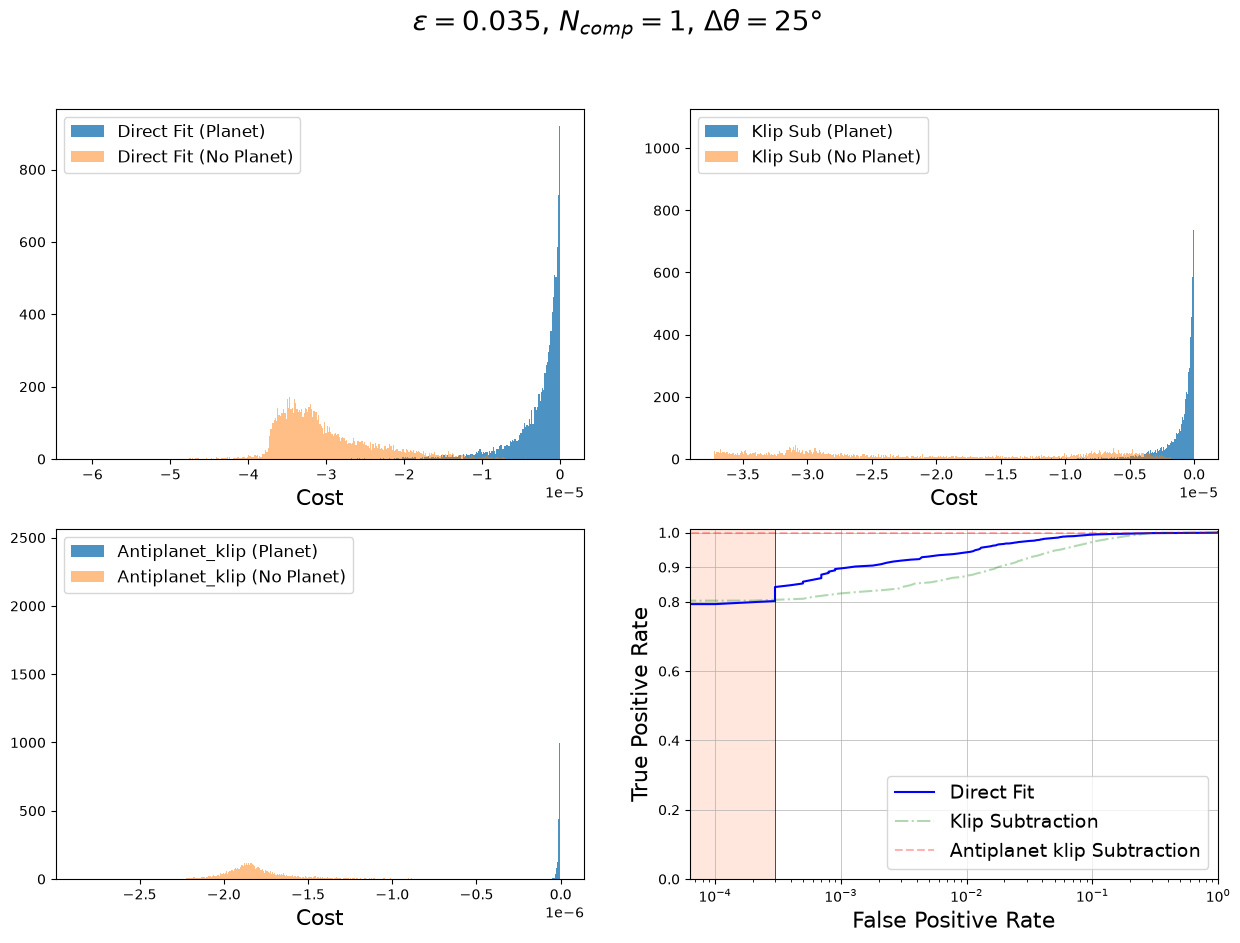

In [161]:
# Generating the full detection limit plot the direct fit method at 25 degrees of sky coverage angle. 

sep_25, theta_25, fr_25 = 0.75, np.pi/9, 0.035
true_planet = pln_psfs_generation(sep_25, theta_25, fr_25)[:,1:5]
direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25 = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, sep_25, theta_25, fr_25, n_comp = 1, verbose = False)
detection_plots_klip(direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25, n_comp = 1,  main_klip_bins = 800, fr = 0.035, roc_klip_alpha=0.3, roc_main_alpha=0.3)
plt.show()

Fig 6

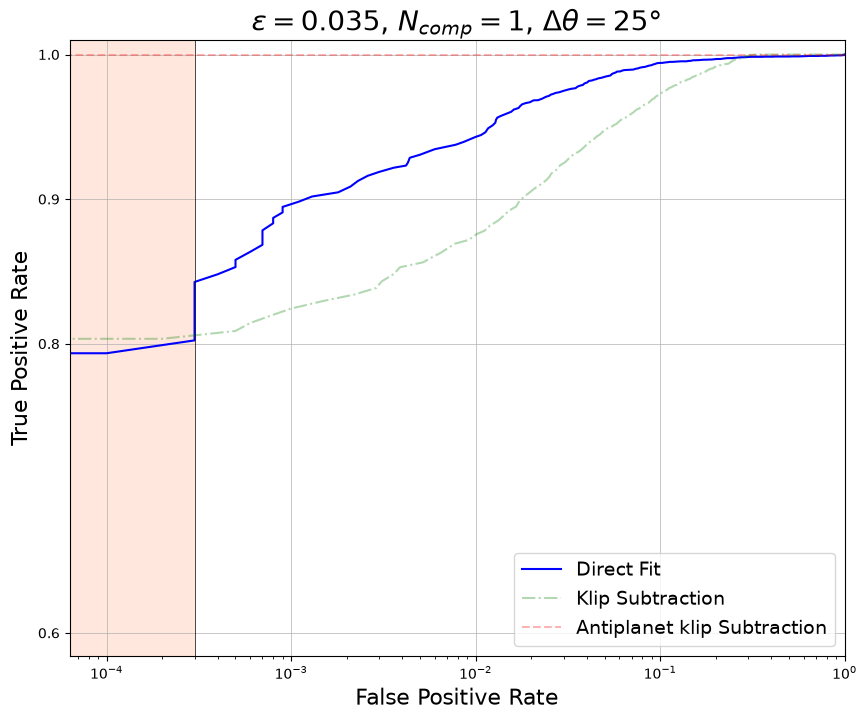

In [152]:
# Generating the direct fit detection limit ROC at 25 degrees of sky coverage angle.

roc_curves_klip(direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25, n_comp = 1,  main_klip_bins = 800, fr = 0.035, roc_klip_alpha=0.3, roc_main_alpha=0.3)
plt.show()

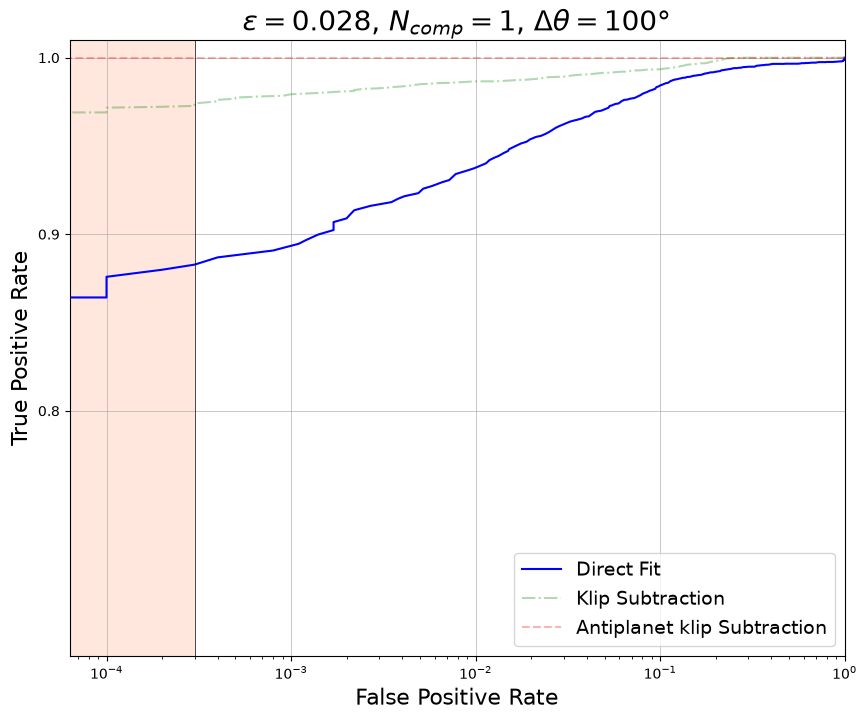

In [ ]:
# Generating the direct fit detection limit ROC at 100 degrees of sky coverage angle.


sep_100, theta_100, fr_100 = 0.75, np.pi/9, 0.028
true_planet = pln_psfs_generation_100(sep_100, theta_100, fr_100)[:,1:5]
direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100 = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, sep_100, theta_100, fr_100, n_comp = 1, verbose = False, angle = 100)
roc_curves_klip(direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100, n_comp = 1,  main_klip_bins = 800, fr = 0.028, sky_coverage = 100, roc_klip_alpha=0.3, roc_main_alpha=0.3)
plt.show()

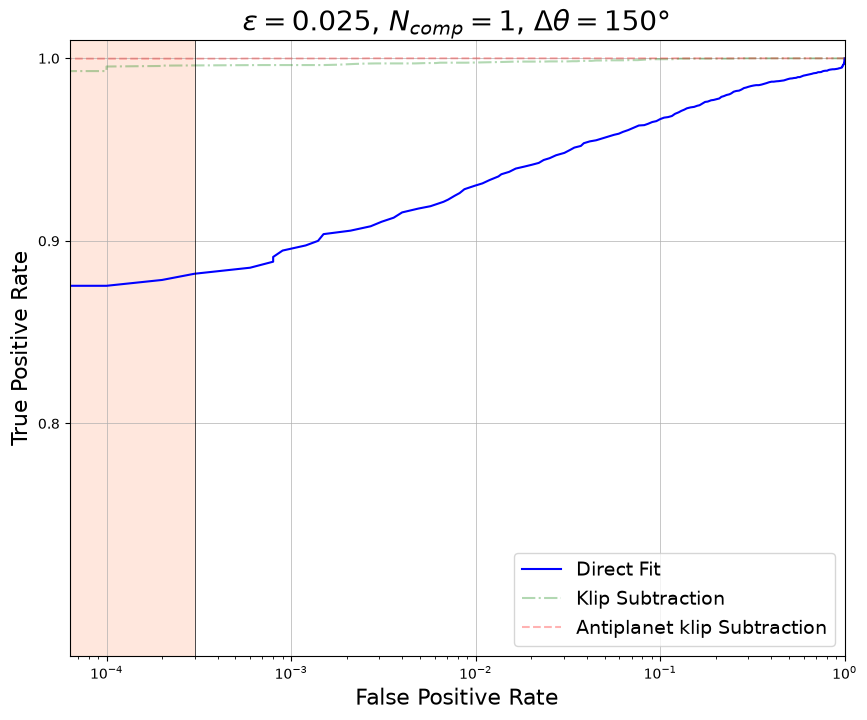

In [ ]:
# Generating the direct fit detection limit ROC at 150 degrees of sky coverage angle.

sep_150, theta_150, fr_150 = 0.75, np.pi/9, 0.025
true_planet = pln_psfs_generation_wider(sep_150, theta_150, fr_150)[:,1:5]
direct_h1_150 , klip_h1_150, main_klip_h1_150, direct_h0_150, klip_h0_150, main_klip_h0_150 = monte_carlo_klip(pln_psfs_star_errs_wide_mc_ez, true_planet, sep_150, theta_150, fr_150, n_comp = 1, verbose = False, angle = 150)
roc_curves_klip(direct_h1_150 , klip_h1_150, main_klip_h1_150, direct_h0_150, klip_h0_150, main_klip_h0_150, n_comp = 1,  main_klip_bins = 800, fr = fr_150, sky_coverage = 150, roc_klip_alpha=0.3, roc_main_alpha=0.3)
plt.show()

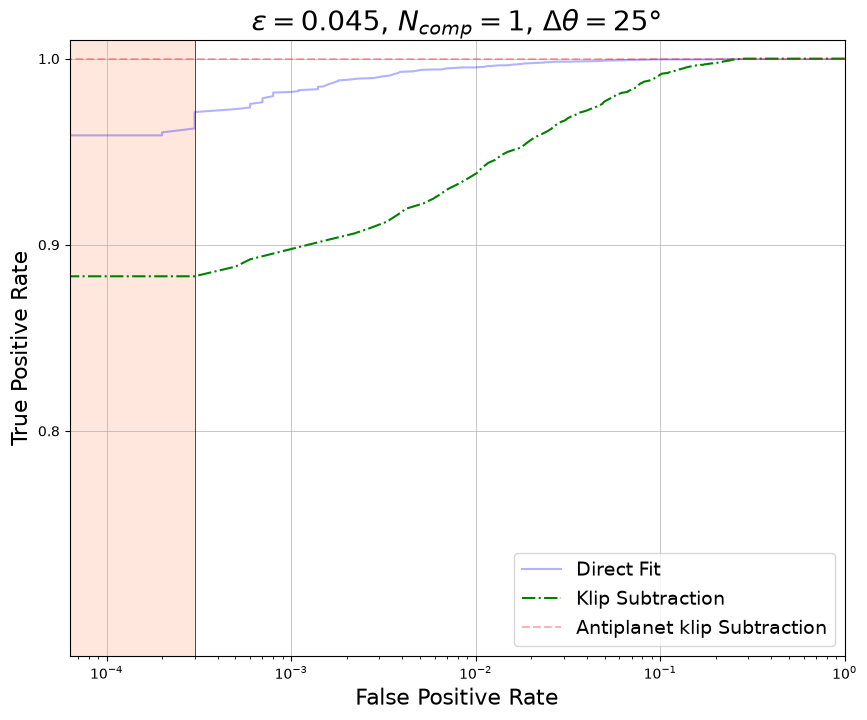

In [155]:
# Generating the KLIP Subtraction detection limit ROC at 25 degrees of sky coverage angle.

sep_25, theta_25, fr_25 = 0.75, np.pi/9, 0.045
true_planet = pln_psfs_generation(sep_25, theta_25, fr_25)[:,1:5]
direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25 = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, sep_25, theta_25, fr_25, n_comp = 1, verbose = False)
roc_curves_klip(direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25, n_comp = 1,  main_klip_bins = 800, fr = 0.045, roc_dir_alpha=0.3, roc_main_alpha=0.3)
plt.show()

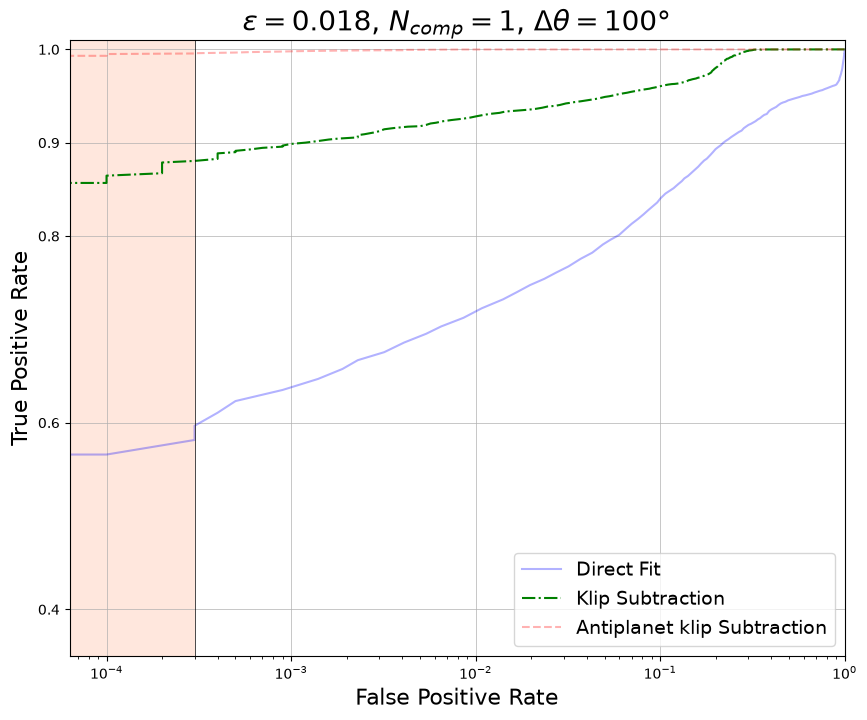

In [ ]:
# Generating the KLIP Subtraction detection limit ROC at 100 degrees of sky coverage angle.

sep_100, theta_100, fr_100 = 0.75, np.pi/9, 0.018
true_planet = pln_psfs_generation_100(sep_100, theta_100, fr_100)[:,1:5]
direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100 = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, sep_100, theta_100, fr_100, n_comp = 1, verbose = False, angle = 100)
roc_curves_klip(direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100, n_comp = 1,  main_klip_bins = 800, fr = 0.018, sky_coverage = 100, roc_dir_alpha=0.3, roc_main_alpha=0.3)
plt.show()

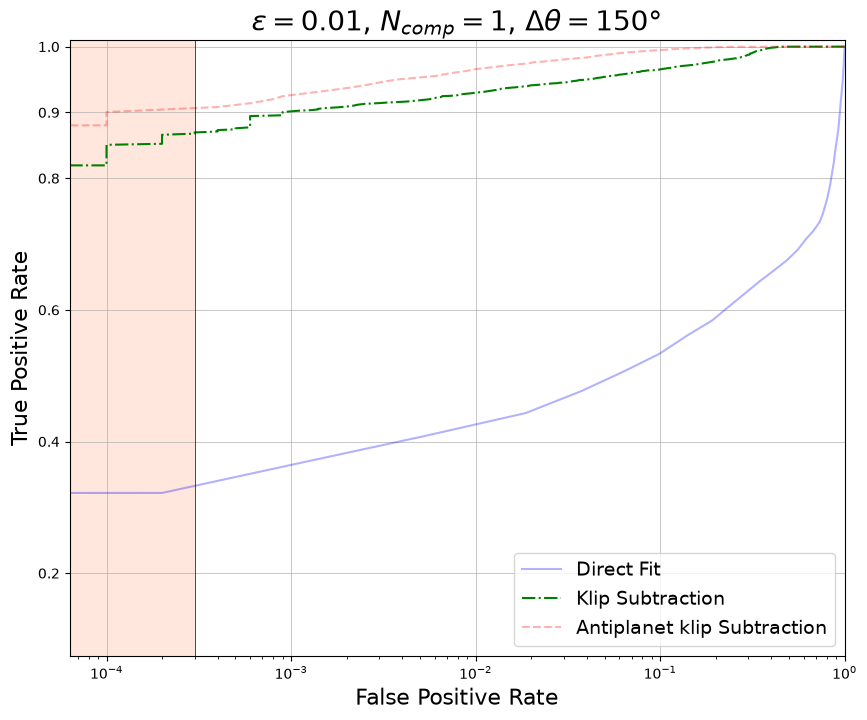

In [157]:
# Generating the KLIP Subtraction detection limit ROC at 150 degrees of sky coverage angle.

sep_150, theta_150, fr_150 = 0.75, np.pi/9, 0.01
true_planet = pln_psfs_generation_wider(sep_150, theta_150, fr_150)[:,1:5]
direct_h1_150 , klip_h1_150, main_klip_h1_150, direct_h0_150, klip_h0_150, main_klip_h0_150 = monte_carlo_klip(pln_psfs_star_errs_wide_mc_ez, true_planet, sep_150, theta_150, fr_150, n_comp = 1, verbose = False, angle = 150)
roc_curves_klip(direct_h1_150 , klip_h1_150, main_klip_h1_150, direct_h0_150, klip_h0_150, main_klip_h0_150, n_comp = 1,  main_klip_bins = 800, fr = fr_150, sky_coverage = 150, roc_dir_alpha=0.3, roc_main_alpha=0.3)
plt.show()

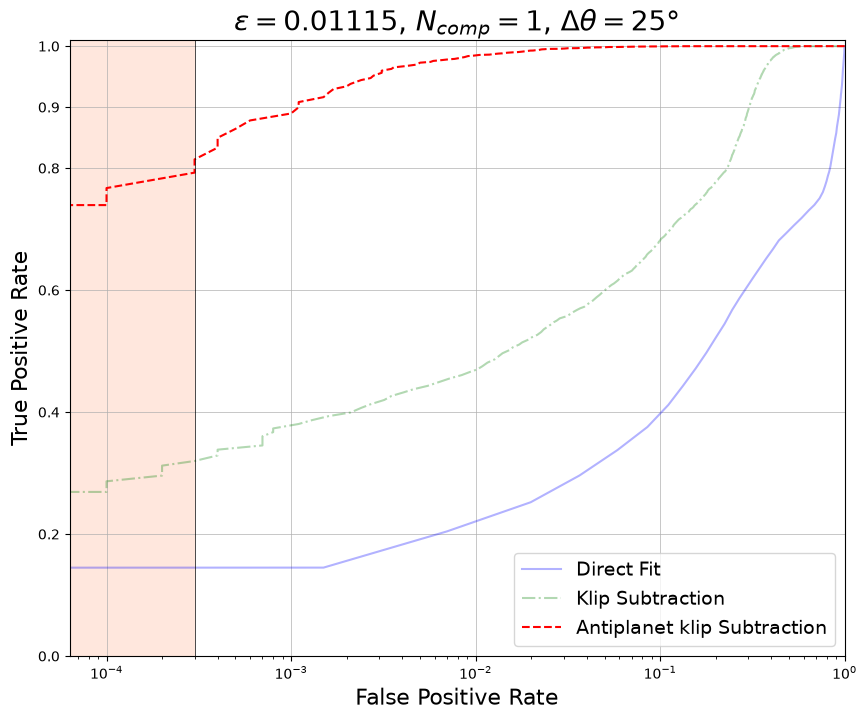

In [ ]:
# Generating the Antiplanet KLIP Subtraction detection limit ROC at 25 degrees of sky coverage angle.

sep_25, theta_25, fr_25 = 0.75, np.pi/9, 0.01115
true_planet = pln_psfs_generation(sep_25, theta_25, fr_25)[:,1:5]
direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25 = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, sep_25, theta_25, fr_25, n_comp = 1, verbose = False)
roc_curves_klip(direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25, n_comp =1,  main_klip_bins = 800, fr = fr_25, roc_dir_alpha=0.3, roc_klip_alpha=0.3)
plt.show()

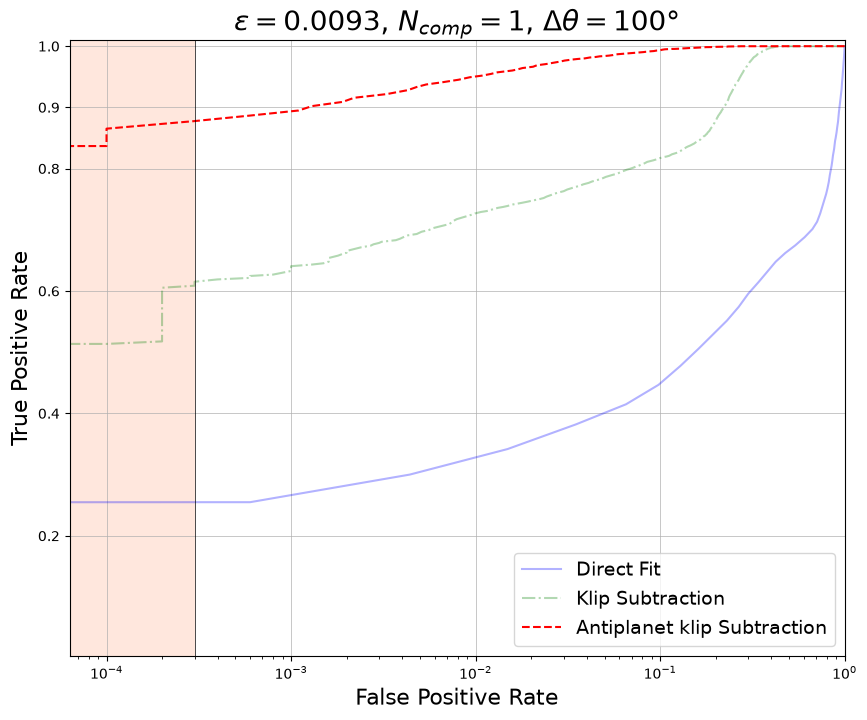

In [ ]:
# Generating the Antiplanet KLIP Subtraction detection limit ROC at 100 degrees of sky coverage angle.

sep_100, theta_100, fr_100 = 0.75, np.pi/9, 0.0093
true_planet = pln_psfs_generation_100(sep_100, theta_100, fr_100)[:,1:5]
direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100 = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, sep_100, theta_100, fr_100, n_comp = 1, verbose = False, angle = 100)
roc_curves_klip(direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100, n_comp = 1,  main_klip_bins = 800, fr = fr_100, sky_coverage = 100, roc_dir_alpha=0.3, roc_klip_alpha=0.3)
plt.show()

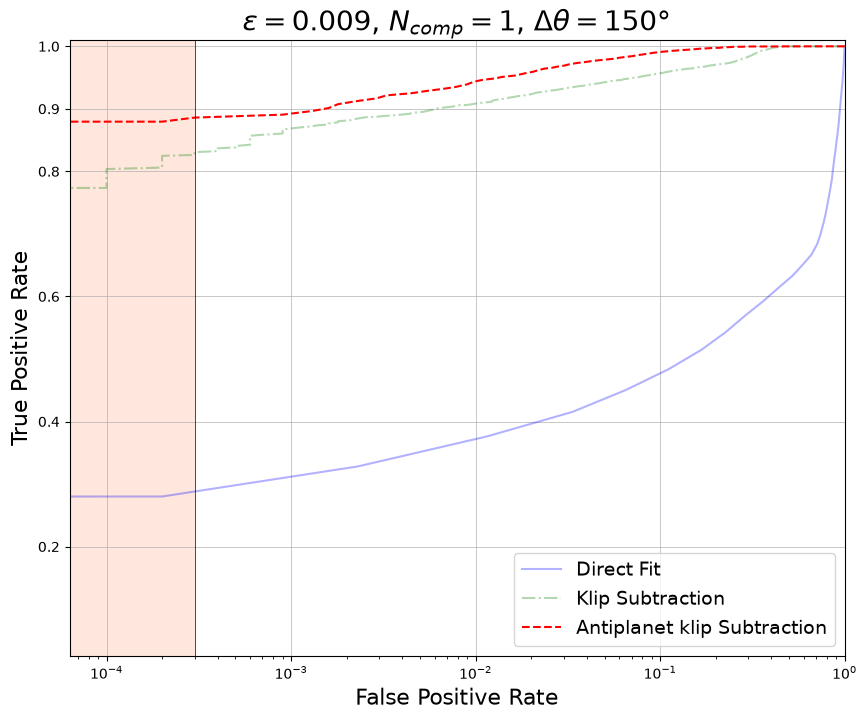

In [ ]:
# Generating the Antiplanet KLIP Subtraction detection limit ROC at 150 degrees of sky coverage angle.

sep_150, theta_150, fr_150 = 0.75, np.pi/9, 0.009
true_planet = pln_psfs_generation_wider(sep_150, theta_150, fr_150)[:,1:5]
direct_h1_150 , klip_h1_150, main_klip_h1_150, direct_h0_150, klip_h0_150, main_klip_h0_150 = monte_carlo_klip(pln_psfs_star_errs_wide_mc_ez, true_planet, sep_150, theta_150, fr_150, n_comp = 1, verbose = False, angle = 150)
roc_curves_klip(direct_h1_150 , klip_h1_150, main_klip_h1_150, direct_h0_150, klip_h0_150, main_klip_h0_150, n_comp = 1,  main_klip_bins = 800, fr = fr_150, sky_coverage = 150, roc_dir_alpha=0.3, roc_klip_alpha=0.3)
plt.show()

<h4>4.2 Localization

In [ ]:
def direct_fit(params, actual_psf):
    # Direct Fit cost function with a given set of parameters (r_hat, theta_hat, FR_hat) and the actual PSF data for localization for 25 degree sky coverage.
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation(r_hat, theta_hat, FR_hat)[:,1:5]
    return ((((actual_psf-planet_hat)))**2).mean()

def klip_sub(params, actual_psf, n_comp = 1):
    # KLIP Subtraction cost function with a given set of parameters (r_hat, theta_hat, FR_hat), the number of componenets, and the actual PSF data for localization for 25 degree sky coverage. 
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation(r_hat, theta_hat, FR_hat)[:,1:5]
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    all_comps = np.zeros((N, n_comp, actual_psf.shape[1]))
    for ang in range (0,N):
        reference_psfs = np.delete(actual_psf, ang, axis=0)
        target_psf = actual_psf[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]  
        all_comps[ang] = components
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    return (((actual_psf-I_star_hat - forward_model_klip(planet_hat, all_comps)))**2).mean()

def main_klip_sub(params, actual_psf, n_comp = 1):
    # Antiplanet KLIP Subtraction cost function with a given set of parameters (r_hat, theta_hat, FR_hat), the number of componenets, and the actual PSF data for localization for 25 degree sky coverage. 
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation(r_hat, theta_hat, FR_hat)[:,1:5]
    I_stellars_hat = actual_psf - planet_hat
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    for ang in range (0,N):
        reference_psfs = np.delete(I_stellars_hat, ang, axis=0)
        target_psf = I_stellars_hat[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]  
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    return (((actual_psf-I_star_hat - planet_hat))**2).mean()

def direct_fit_100(params, actual_psf):
    # Direct Fit cost function with a given set of parameters (r_hat, theta_hat, FR_hat) and the actual PSF data for localization for 100 degree sky coverage.
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation_100(r_hat, theta_hat, FR_hat)[:,1:5]
    return ((((actual_psf-planet_hat)))**2).mean()

def klip_sub_100(params, actual_psf, n_comp = 1):
    # KLIP Subtraction cost function with a given set of parameters (r_hat, theta_hat, FR_hat), the number of componenets, and the actual PSF data for localization for 100 degree sky coverage. 
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation_100(r_hat, theta_hat, FR_hat)[:,1:5]
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    all_comps = np.zeros((N, n_comp, actual_psf.shape[1]))
    for ang in range (0,N):
        reference_psfs = np.delete(actual_psf, ang, axis=0)
        target_psf = actual_psf[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]
        all_comps[ang] = components
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    return (((actual_psf-I_star_hat - forward_model_klip(planet_hat, all_comps)))**2).mean()

def main_klip_sub_100(params, actual_psf, n_comp = 1):
    # Antiplanet KLIP Subtraction cost function with a given set of parameters (r_hat, theta_hat, FR_hat), the number of componenets, and the actual PSF data for localization for 100 degree sky coverage. 
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation_100(r_hat, theta_hat, FR_hat)[:,1:5]
    I_stellars_hat = actual_psf - planet_hat
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    for ang in range (0,N):
        reference_psfs = np.delete(I_stellars_hat, ang, axis=0)
        target_psf = I_stellars_hat[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]  
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    return (((actual_psf-I_star_hat - planet_hat))**2).mean()

def direct_fit_150(params, actual_psf):
    # Direct Fit cost function with a given set of parameters (r_hat, theta_hat, FR_hat) and the actual PSF data for localization for 150 degree sky coverage.
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation_wider(r_hat, theta_hat, FR_hat)[:,1:5]
    return ((((actual_psf-planet_hat)))**2).mean()

def klip_sub_150(params, actual_psf, n_comp = 1):
    # KLIP Subtraction cost function with a given set of parameters (r_hat, theta_hat, FR_hat), the number of componenets, and the actual PSF data for localization for 150 degree sky coverage. 
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation_wider(r_hat, theta_hat, FR_hat)[:,1:5]
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    all_comps = np.zeros((N, n_comp, actual_psf.shape[1]))
    for ang in range (0,N):
        reference_psfs = np.delete(actual_psf, ang, axis=0)
        target_psf = actual_psf[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]
        all_comps[ang] = components  
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    return (((actual_psf-I_star_hat - forward_model_klip(planet_hat, all_comps)))**2).mean()

def main_klip_sub_150(params, actual_psf, n_comp = 1):
    # Antiplanet KLIP Subtraction cost function with a given set of parameters (r_hat, theta_hat, FR_hat), the number of componenets, and the actual PSF data for localization for 150 degree sky coverage. 
    r_hat , theta_hat, FR_hat = params
    planet_hat = pln_psfs_generation_wider(r_hat, theta_hat, FR_hat)[:,1:5]
    I_stellars_hat = actual_psf - planet_hat
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    for ang in range (0,N):
        reference_psfs = np.delete(I_stellars_hat, ang, axis=0)
        target_psf = I_stellars_hat[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]  
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    return (((actual_psf-I_star_hat - planet_hat))**2).mean()

def direct_fit_tuning(planet, star_psf, test_seps, test_thetas, test_frs, hund= False, hund_fif = False):
    #  Tuning function for localization parameter grids for the direct fitting method
    actual_pln_psf = star_psf[:,1:5] + planet
    costs_pln_planet = np.zeros((len(test_seps), len(test_thetas), len(test_frs)))
    for isep, sep in enumerate(test_seps):
        for ithet, thet in enumerate(test_thetas):
            for ifr, fr in enumerate(test_frs):
                if hund:
                    cost_val= direct_fit_100((sep, thet, fr), actual_pln_psf)
                elif hund_fif:
                    cost_val= direct_fit_150((sep, thet, fr), actual_pln_psf)
                else:
                    cost_val= direct_fit((sep, thet, fr), actual_pln_psf)
                costs_pln_planet[isep, ithet, ifr] = cost_val
    min_index_flat = np.argmin(costs_pln_planet)
    min_index_3d = np.unravel_index(min_index_flat, costs_pln_planet.shape)
    final_min_params = np.array([test_seps[min_index_3d[0]], test_thetas[min_index_3d[1]], test_frs[min_index_3d[2]]])
    return (final_min_params, costs_pln_planet)

def klip_sub_tuning(planet, star_psf, test_seps, test_thetas, test_frs, hund = False, hund_fif = False):
    #  Tuning function for localization parameter grids for the KLIP Subtraction method
    actual_pln_psf = star_psf[:,1:5] + planet
    costs_pln_planet = np.zeros((len(test_seps), len(test_thetas), len(test_frs)))
    for isep, sep in enumerate(test_seps):
        for ithet, thet in enumerate(test_thetas):
            for ifr, fr in enumerate(test_frs):
                if hund:
                    cost_val= klip_sub_100((sep, thet, fr), actual_pln_psf)
                elif hund_fif:
                    cost_val= klip_sub_150((sep, thet, fr), actual_pln_psf)
                else:
                    cost_val= klip_sub((sep, thet, fr), actual_pln_psf)
                costs_pln_planet[isep, ithet, ifr] = cost_val
    min_index_flat = np.argmin(costs_pln_planet)
    min_index_3d = np.unravel_index(min_index_flat, costs_pln_planet.shape)
    final_min_params = np.array([test_seps[min_index_3d[0]], test_thetas[min_index_3d[1]], test_frs[min_index_3d[2]]])
    return (final_min_params, costs_pln_planet)

def main_klip_sub_tuning(planet, star_psf, test_seps, test_thetas, test_frs, hund = False, hund_fif = False):
    #  Tuning function for localization parameter grids for the Antiplanet KLIP Subtraqction method
    actual_pln_psf = star_psf[:,1:5] + planet
    costs_pln_planet = np.zeros((len(test_seps), len(test_thetas), len(test_frs)))
    for isep, sep in enumerate(test_seps):
        for ithet, thet in enumerate(test_thetas):
            for ifr, fr in enumerate(test_frs):
                if hund:
                    cost_val= main_klip_sub_100((sep, thet, fr), actual_pln_psf)
                elif hund_fif:
                    cost_val= main_klip_sub_150((sep, thet, fr), actual_pln_psf)
                else:
                    cost_val= main_klip_sub((sep, thet, fr), actual_pln_psf)
                costs_pln_planet[isep, ithet, ifr] = cost_val
    min_index_flat = np.argmin(costs_pln_planet)
    min_index_3d = np.unravel_index(min_index_flat, costs_pln_planet.shape)
    final_min_params = np.array([test_seps[min_index_3d[0]], test_thetas[min_index_3d[1]], test_frs[min_index_3d[2]]])
    return (final_min_params, costs_pln_planet)

def localization_arrays(data_theta, data_fr, test_FRs, method  , coverage,
                        data_sep = 0.75, test_seps = np.arange(0,2.25,0.25), 
                        test_thetas = np.linspace(0,np.pi, 19, endpoint=True), 
                        big_dataset = pln_psfs_star_mc_ez, n_datasets = 10, verbose = True):
    
    #  Function that uses the tuning function to across localization datasets and generates the trfue planet at the right sky coverage, and returns the entire cost grid, cost value of the correct parameters for each dataset, lowest cost values for each dataset, and the parameters corresponding to those costs.
    if coverage == 25:
        planet_psf_detlim = pln_psfs_generation(data_sep, data_theta, data_fr)[:,1:5]
    elif coverage == 100:
        planet_psf_detlim = pln_psfs_generation_100(data_sep, data_theta, data_fr)[:,1:5]
    elif coverage == 150:
        planet_psf_detlim = pln_psfs_generation_wider(data_sep, data_theta, data_fr)[:,1:5]
    datasets = big_dataset[0:n_datasets]
    min_detlim = np.zeros((len(datasets), 3))
    cost_pln_detlim = np.zeros((len(datasets), len(test_seps), len(test_thetas), len(test_FRs)))
    for id, d in enumerate (datasets):
        if verbose:
            print(f"Now on Datset : {id}")
        if method == "direct":
            if coverage == 25:
                min_detlim[id], cost_pln_detlim[id] = direct_fit_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs)
            elif coverage == 100:
                min_detlim[id], cost_pln_detlim[id] = direct_fit_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund = True)
            elif coverage == 150:
                min_detlim[id], cost_pln_detlim[id] = direct_fit_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund_fif = True)
            else:
                raise ValueError("Wrong coverage value")
        
        elif method == "klip":
            if coverage == 25:
                min_detlim[id], cost_pln_detlim[id] = klip_sub_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs)
            elif coverage == 100:
                min_detlim[id], cost_pln_detlim[id] = klip_sub_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund = True)
            elif coverage == 150:
                min_detlim[id], cost_pln_detlim[id] = klip_sub_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund_fif = True)
            else:
                raise ValueError("Wrong coverage value")
        
        elif method == "klip_antiplanet":
            if coverage == 25:
                min_detlim[id], cost_pln_detlim[id] = main_klip_sub_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs)
            elif coverage == 100:
                min_detlim[id], cost_pln_detlim[id] = main_klip_sub_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund = True)
            elif coverage == 150:
                min_detlim[id], cost_pln_detlim[id] = main_klip_sub_tuning(planet_psf_detlim, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund_fif = True)
            else:
                raise ValueError("Wrong coverage value")
        
        else:
            raise ValueError("Wrong method")
     
    optim_fr = test_FRs[np.argmin(np.abs(test_FRs - data_fr))]
    optim_costs_detlim= [cost_pln_detlim[i, np.where(test_seps == data_sep)[0][0], np.where(test_thetas == data_theta)[0][0], 
                                                np.where(test_FRs == optim_fr)[0][0]] for i in range(cost_pln_detlim.shape[0])]
    min_costs_detlim = [np.min(cost_pln_detlim[i]) for i in range(cost_pln_detlim.shape[0])]
    return (cost_pln_detlim, optim_costs_detlim, min_costs_detlim, min_detlim)

def prob_measures(all_cost_vals, data_id, dataset_axis = 0, sep_axis = 1, theta_axis= 2, fr_axis= 3):
    # Function that takes the cost grid from localiztion and converts them to the correct joint and marginal probability distributions.
    cost_alld_probs = np.exp(-all_cost_vals[data_id]/2)
    theta_fr_prob_measure = np.sum(cost_alld_probs, axis = sep_axis-1)
    sep_dist = np.sum(cost_alld_probs, axis = (theta_axis-1,fr_axis-1))
    sep_fr_prob_measure = np.sum(cost_alld_probs, axis = theta_axis -1)
    theta_dist= np.sum(cost_alld_probs, axis = (sep_axis -1,fr_axis-1))
    sep_theta_prob_measure = np.sum(cost_alld_probs, axis = fr_axis -1)
    fr_dist= np.sum(cost_alld_probs, axis = (sep_axis -1,theta_axis-1))

    return (theta_fr_prob_measure, sep_fr_prob_measure, sep_theta_prob_measure, sep_dist, theta_dist, fr_dist)

def corner_plots(all_cost_vals, detection_lim, data_deg, test_seps, test_theta, test_fr, method, Det_method, real_params, dataset_axis = 0, sep_axis = 1, theta_axis= 2, fr_axis= 3, cmap = "viridis", 
                 levels = 100, pred_mins = False, pred_mins_avgd = None, data_id =  5, save = False, address = None, dataset_id_title = None):
    
    # Function that takes the cost grid from localiztion and generates the corner plots for the joint and marginal probability distributions.
    theta_fr_prob_measure, sep_fr_prob_measure, sep_theta_prob_measure, sep_dist, theta_dist, fr_dist = prob_measures(all_cost_vals, data_id =  data_id, dataset_axis = dataset_axis, 
                                                                                                                      sep_axis = sep_axis, theta_axis= theta_axis, 
                                                                                                                      fr_axis= fr_axis)
    sep, theta, fr = real_params
    fig, axs = plt.subplots(3,3, figsize = (15,10))

    vmin = min(np.min(sep_theta_prob_measure), 
               np.min(sep_fr_prob_measure), 
               np.min(theta_fr_prob_measure))
    vmax = max(np.max(sep_theta_prob_measure), 
               np.max(sep_fr_prob_measure), 
               np.max(theta_fr_prob_measure))

    axs[0, 0].plot(test_seps, sep_dist)
    axs[1, 1].plot(test_theta, theta_dist)
    axs[2, 2].plot(test_fr, fr_dist)
    log_levels = [np.logspace(np.log10(np.nanmin(i)), np.log10(np.nanmax(i)), num=levels) for i in [sep_theta_prob_measure,sep_fr_prob_measure, theta_fr_prob_measure]]
    cs1 = axs[1, 0].contourf(test_seps, test_theta, sep_theta_prob_measure.T, levels = log_levels[0], cmap=cmap, norm=LogNorm())
    cs2 = axs[2, 0].contourf(test_seps, test_fr, sep_fr_prob_measure.T, levels=log_levels[1], cmap=cmap, norm=LogNorm())
    cs3 = axs[2, 1].contourf(test_theta, test_fr, theta_fr_prob_measure.T, levels=log_levels[2], cmap=cmap, norm=LogNorm())
    
    axs[1, 0].scatter(sep, theta, c="red", marker="s", label="real_params", s=3)
    axs[2, 0].scatter(sep, fr, c="red", marker="s", s=3)
    axs[2, 1].scatter(theta, fr, c="red", marker="s", s=3)

    cbar1 = fig.colorbar(cs1, ax=axs[1, 0], orientation='vertical', shrink=0.7)
    cbar1.ax.tick_params(labelsize=10)

    cbar2 = fig.colorbar(cs2, ax=axs[2, 0], orientation='vertical', shrink=0.7)
    cbar2.ax.tick_params(labelsize=10)

    cbar3 = fig.colorbar(cs3, ax=axs[2, 1], orientation='vertical', shrink=0.7)
    cbar3.ax.tick_params(labelsize=10)

    axs[1, 0].set_ylabel(r"$\Theta$", fontsize = 12)
    axs[0, 0].set_ylabel(r"$r$", fontsize = 12)
    axs[2, 0].set_ylabel(r"$\epsilon$", fontsize = 12)
    axs[2, 0].set_xlabel(r"$r$", fontsize = 12)
    axs[2, 1].set_xlabel(r"$\Theta$", fontsize = 12)
    axs[2, 2].set_xlabel(r"$\epsilon$", fontsize = 12)

    fig.delaxes(axs[0, 1])
    fig.delaxes(axs[0, 2])
    fig.delaxes(axs[1, 2])

    if pred_mins:
        formatted_list = [f'{value:.2f}' for value in pred_mins_avgd]
        fig.text(0.8, 0.7, f'Predicted Params : {formatted_list}', horizontalalignment='right', verticalalignment='top', fontsize = 12)
        formatted_tuple = (f'{real_params[0]:.2f}', f'{real_params[1]:.2f}', f'{real_params[2]:.2f}')
        fig.text(0.8, 0.68, f'Actual Params : {formatted_tuple}', horizontalalignment='right', verticalalignment='top', fontsize = 12)
    else:
        formatted_tuple = (f'{real_params[0]:.2f}', f'{real_params[1]:.2f}', f'{real_params[2]:.2f}')
        fig.text(0.8, 0.68, f'Actual Params : {formatted_tuple}', horizontalalignment='right', verticalalignment='top')

    fig.legend(bbox_to_anchor=(0.8, 0.75), fontsize = 12)
    plt.subplots_adjust(wspace=0.8) 
    if dataset_id_title:
        fig.suptitle(f"{method} for " +r"$\Delta \theta = $" + f"{data_deg}\u00b0 at the {Det_method} "+ r"$\epsilon_{detlim}$ =" +f"{detection_lim}, for dataset {dataset_id_title}", fontsize = 16)  
    else:
        fig.suptitle(f"{method} for " +r"$\Delta \theta = $" + f"{data_deg}\u00b0 at the {Det_method} "+ r"$\epsilon_{detlim}$ =" +f"{detection_lim}, for dataset {data_id}", fontsize = 16)  
    if save == True:
        plt.savefig(address, dpi = 300, bbox_inches = "tight")
        plt.clf() 
        plt.close()
        print(f"dataset {data_id} saved")
    else:
        plt.show()


Fig 7

Note below that the argument `dataset_id_title` differs from the argument `data_id`. That happens here since running `localization arrays()` on a singular pre indexed dataset gives a cost array with only 1 element in the dataset dimension. We chose this dataset to be the dataset with index 1 by selecting `pln_psfs_star_mc_ez[1]`. However, these functions are written to run on multiple datasets at once with more than a single element in the dataset dimension where the `data_id` index would match what needs to go in the plot title, and you wouldn't need the argument `dataset_id_title`. 

Also note the variable conventions for storing the result from `localization arrays()`. The cost grid, cost value of the correct parameters for each dataset, and the lowest cost values for each dataset are stored with the suffix `_detection limit method_localization method`. The final output which stores the parameters which correspond to the minimum cost is stored as `min_localization method_ detection limit method`. 

Localization is compute heavy to run for all datasets, for each method, at every other method's detection limit and for every sky coverage angle. While the barebones code is given here for you to reproduce those localizations if you wish, the data from these localizations is saved in the `localization_data` folder available on the zenodo release of this repository. The data in that folder is saved with the same naming convention.

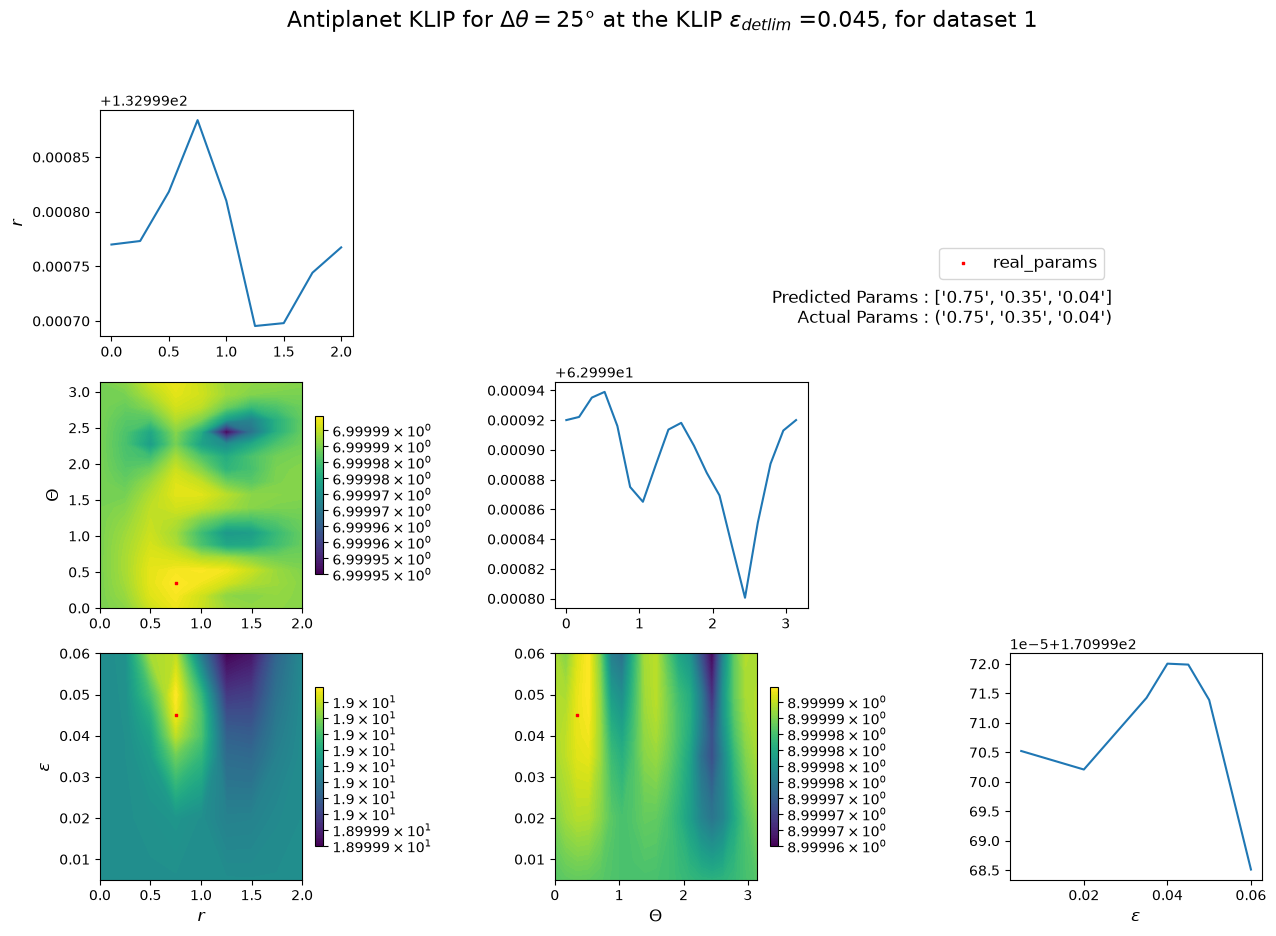

In [ ]:
# Code to perform localization using the Antiplanet KLIP Subtraction method for a dataset with 25 degrees of sky coverage angle, a separation of 0.75, a theta of pi/9, and a flux ratio of 0.045 (the KLIP Subtraction detection limit). 
# The code generates the cost grid and creates corner plots to visualize the joint and marginal probability distributions of the localization parameters.

KLIP_detlim_test_FRS = np.array([0.005, 0.02, 0.035, 0.04, 0.045, 0.05, 0.06])
test_thetas = np.linspace(0,np.pi, 19, endpoint=True)
cost_pln_KLIP_detlim_anti_KLIP, optim_costs_KLIP_detlim_anti_KLIP, min_costs_KLIP_detlim_anti_KLIP, min_antiKLIP_KLIP = localization_arrays(data_theta = np.pi/9, data_fr = 0.045, test_FRs = KLIP_detlim_test_FRS,
                     method = "klip_antiplanet"  , coverage = 25,
                        data_sep = 0.75, test_seps = np.arange(0,2.25,0.25), 
                        test_thetas = test_thetas, 
                        big_dataset = pln_psfs_star_mc_ez[1][np.newaxis, :], verbose = False)
corner_plots(cost_pln_KLIP_detlim_anti_KLIP,  0.045, 25, np.arange(0,2.25,0.25), 
    test_thetas, KLIP_detlim_test_FRS, "Antiplanet KLIP", "KLIP", (0.75, np.pi/9, 0.045),
    pred_mins = True, pred_mins_avgd= min_antiKLIP_KLIP[0], data_id =0, dataset_id_title=1)

<h4> 4.3 Detection Testing For Robustness

In [66]:
def detection_plots_klip_robust(h1_pert, h0_pert, h1_nonpert, h0_nonpert, true_params, test_params, method, direct_bins = 400, main_klip_bins = 800, klip_bins = 800, sky_coverage = 25, xlim_right = 1.00, roc_legend = "lower right", plot_all = False):
    # Function that generates the detection plots for the Antiplanet KLIP Subtraction method, KLIP Subtraction method, and Direct Fitting method for a given set of perturbed and non-perturbed cost values. 
    max_pert_h0 = np.max(h0_pert)
    min_pert_h1 = np.min(h1_pert)
    min_pert_h0 = np.min(h0_pert)
    max_pert_h1 = np.max(h1_pert)
    min_pert = np.min(np.hstack((h1_pert,h0_pert)))
    max_pert = np.max(np.hstack((h1_pert,h0_pert)))
    max_nonpert_h0 = np.max(h0_nonpert)
    min_nonpert_h1 = np.min(h1_nonpert)
    min_nonpert_h0 = np.min(h0_nonpert)
    max_nonpert_h1 = np.max(h1_nonpert)
    min_nonpert = np.min(np.hstack((h1_nonpert,h0_nonpert)))
    max_nonpert = np.max(np.hstack((h1_nonpert,h0_nonpert)))
    if method == "Direct":
        bins_use = direct_bins
    elif method == "KLIP":
        bins_use = klip_bins
    elif method == "Antiplanet KLIP":
        bins_use = main_klip_bins
    if (min_pert_h1>max_pert_h0) or (min_pert_h0>max_pert_h1):
        bins_pert = np.linspace(min_pert,max_pert,bins_use)
    elif min_pert_h1 < max_pert_h0:
        bins_pert = np.array([min_pert]+list(np.linspace(min_pert_h0,max_pert_h1,bins_use)) + [max_pert])
    else:
        bins_pert = np.array([min_pert]+list(np.linspace(min_pert_h1,max_pert_h0,bins_use)) + [max_pert])
    if (min_nonpert_h1>max_nonpert_h0) or (min_nonpert_h0>max_nonpert_h1):
        bins_nonpert = np.linspace(min_nonpert,max_nonpert,bins_use)
    elif min_nonpert_h1 < max_nonpert_h0:
        bins_nonpert = np.array([min_nonpert]+list(np.linspace(min_nonpert_h0,max_nonpert_h1,bins_use)) + [max_nonpert])
    else:
        bins_nonpert = np.array([min_nonpert]+list(np.linspace(min_nonpert_h1,max_nonpert_h0,bins_use)) + [max_nonpert])


    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, height_ratios=[1, 1])  
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax4 = fig.add_subplot(gs[1, :])

    box = ax4.get_position() 
    ax4.set_position([box.x0 + 0.25, box.y0, box.width * 0.5, box.height])  
    if plot_all:
        ax1.hist(h1_pert, bins = bins_use, alpha=0.8, label='Perturbed Signal Parameters  (Planet)'   )
        ax1.hist(h0_pert, bins = bins_use, alpha=0.5, label='Perturbed Signal Parameters  (No Planet)')
    else:
        ax1.hist(h1_pert, bins= bins_pert[1:-1], alpha=0.8, label='Perturbed Signal Parameters  (Planet)'   )
        ax1.hist(h0_pert, bins= bins_pert[1:-1], alpha=0.5, label='Perturbed Signal Parameters  (No Planet)')
    ax2.hist(h1_nonpert, bins = bins_nonpert[1:-1], alpha=0.8, label='True Signal Paramters (Planet)')
    ax2.hist(h0_nonpert, bins = bins_nonpert[1:-1], alpha=0.5, label='True Signal Paramters (No Planet)')
    ax1.set_xlabel(r'Cost', fontsize = 16)
    ax1.legend(loc='upper left', fontsize = 12)
    ax2.set_xlabel(r'Cost' , fontsize = 16)
    ax2.legend(loc='upper left', fontsize = 12)
    ax4.set_xlabel(r'Cost' , fontsize = 16)
    ax4.legend(loc='upper left', fontsize = 12)
    pert_tpr_array = np.zeros(len(bins_pert))
    pert_fpr_array = np.zeros(len(bins_pert))
    nonpert_tpr_array = np.zeros(len(bins_nonpert))
    nonpert_fpr_array = np.zeros(len(bins_nonpert))
    for n in range(len(bins_pert)):
        pert_tpr_array[n] = float(len(h1_pert[h1_pert>=bins_pert[n]]))/float(len(h1_pert))
        pert_fpr_array[n] = float(len(h0_pert[h0_pert>=bins_pert[n]]))/float(len(h0_pert))
    for n in range(len(bins_nonpert)):
        nonpert_tpr_array[n] = float(len(h1_nonpert[h1_nonpert>=bins_nonpert[n]]))/float(len(h1_nonpert))
        nonpert_fpr_array[n] = float(len(h0_nonpert[h0_nonpert>=bins_nonpert[n]]))/float(len(h0_nonpert))
    x_line = 3.0/float(len(h0_pert))
    ax4.semilogx(pert_fpr_array,pert_tpr_array,label='Perturbed Signal Fit',linestyle='-',color='red')
    ax4.semilogx(nonpert_fpr_array,nonpert_tpr_array,label='True Signal Fit',linestyle='-.',color='green')
    ax4.axvline(x_line,color='k',lw='.5')
    ax4.axvspan(0,x_line,facecolor='#FFA07A', alpha=0.25)
    ax4.grid(True,linewidth=0.5)
    ax4.set_xlim(right=xlim_right)
    fig.suptitle(f" {method} Detection Robustness at "+ r"$\Delta \theta = $" +f"{sky_coverage}\u00B0\n True Params: {np.array2string(true_params, precision=3)}\n Test Params: {np.array2string(test_params, precision=3)}", fontsize = 20)
    y_ticks = ax4.get_yticks()
    y_ticks = np.insert(y_ticks, -1, 0.9)
    ax4.set_yticks(y_ticks)
    plt.ylim((0.0,1.01))
    plt.xlabel("False Positive Rate", fontsize = 16)
    plt.ylabel("True Positive Rate", fontsize = 16)
    ax4.legend(loc = roc_legend, fontsize = 14)   

def roc_curves_klip_robust(h1_pert, h0_pert, h1_nonpert, h0_nonpert, true_params, test_params, method, direct_bins = 400, main_klip_bins = 800, klip_bins = 800, sky_coverage = 25, xlim_right = 1.00, roc_legend = "lower right"):
    # Function that plots only the ROC cuurves for the Antiplanet KLIP Subtraction method, KLIP Subtraction method, and Direct Fitting method for a given set of perturbed and non-perturbed cost values. 
    max_pert_h0 = np.max(h0_pert)
    min_pert_h1 = np.min(h1_pert)
    min_pert_h0 = np.min(h0_pert)
    max_pert_h1 = np.max(h1_pert)
    min_pert = np.min(np.hstack((h1_pert,h0_pert)))
    max_pert = np.max(np.hstack((h1_pert,h0_pert)))
    max_nonpert_h0 = np.max(h0_nonpert)
    min_nonpert_h1 = np.min(h1_nonpert)
    min_nonpert_h0 = np.min(h0_nonpert)
    max_nonpert_h1 = np.max(h1_nonpert)
    min_nonpert = np.min(np.hstack((h1_nonpert,h0_nonpert)))
    max_nonpert = np.max(np.hstack((h1_nonpert,h0_nonpert)))
    if method == "Direct":
        bins_use = direct_bins
    elif method == "KLIP":
        bins_use = klip_bins
    elif method == "Antiplanet KLIP":
        bins_use = main_klip_bins
    if (min_pert_h1>max_pert_h0) or (min_pert_h0>max_pert_h1):
        bins_pert = np.linspace(min_pert,max_pert,bins_use)
    elif min_pert_h1 < max_pert_h0:
        bins_pert = np.array([min_pert]+list(np.linspace(min_pert_h0,max_pert_h1,bins_use)) + [max_pert])
    else:
        bins_pert = np.array([min_pert]+list(np.linspace(min_pert_h1,max_pert_h0,bins_use)) + [max_pert])
    if (min_nonpert_h1>max_nonpert_h0) or (min_nonpert_h0>max_nonpert_h1):
        bins_nonpert = np.linspace(min_nonpert,max_nonpert,bins_use)
    elif min_nonpert_h1 < max_nonpert_h0:
        bins_nonpert = np.array([min_nonpert]+list(np.linspace(min_nonpert_h0,max_nonpert_h1,bins_use)) + [max_nonpert])
    else:
        bins_nonpert = np.array([min_nonpert]+list(np.linspace(min_nonpert_h1,max_nonpert_h0,bins_use)) + [max_nonpert])
    pert_tpr_array = np.zeros(len(bins_pert))
    pert_fpr_array = np.zeros(len(bins_pert))
    nonpert_tpr_array = np.zeros(len(bins_nonpert))
    nonpert_fpr_array = np.zeros(len(bins_nonpert))
    for n in range(len(bins_pert)):
        pert_tpr_array[n] = float(len(h1_pert[h1_pert>=bins_pert[n]]))/float(len(h1_pert))
        pert_fpr_array[n] = float(len(h0_pert[h0_pert>=bins_pert[n]]))/float(len(h0_pert))
    for n in range(len(bins_nonpert)):
        nonpert_tpr_array[n] = float(len(h1_nonpert[h1_nonpert>=bins_nonpert[n]]))/float(len(h1_nonpert))
        nonpert_fpr_array[n] = float(len(h0_nonpert[h0_nonpert>=bins_nonpert[n]]))/float(len(h0_nonpert))
    x_line = 3.0/float(len(h0_pert))
    pert_tpr_min = pert_tpr_array[np.argmin(pert_fpr_array)]
    nonpert_tpr_min = nonpert_tpr_array[np.argmin(nonpert_fpr_array)]
    plt.figure(figsize = (10, 8))
    plt.semilogx(pert_fpr_array,pert_tpr_array,label='Perturbed Signal Fit',linestyle='-',color='red')
    plt.semilogx(nonpert_fpr_array,nonpert_tpr_array,label='True Signal Fit',linestyle='-.',color='green')
    plt.axvline(x_line,color='k',lw='.5')
    plt.axvspan(0,x_line,facecolor='#FFA07A', alpha=0.25)
    plt.grid(True,linewidth=0.5)
    plt.xlim(right=xlim_right)
    plt.title(f" ROC for {method} Detection Robustness at "+ r"$\Delta \theta = $" +f"{sky_coverage}\u00B0\n True Params: {np.array2string(true_params, precision=3)}\n Test Params: {np.array2string(test_params, precision=3)}", fontsize = 20)
    y_ticks = plt.gca().get_yticks()
    y_ticks = np.insert(y_ticks, -1, 0.9)
    plt.yticks(y_ticks)
    min_tpr = min(pert_tpr_min, nonpert_tpr_min)
    min_tpr = max(min_tpr - 0.2, 0)  
    plt.ylim((min_tpr,1.01))
    plt.xlabel("False Positive Rate", fontsize =16)
    plt.ylabel("True Positive Rate", fontsize = 16)
    plt.legend(loc = roc_legend, fontsize = 14)   
    

In [177]:
# These true parameters are defined per the detection limit of each method where each method's true params are (r =0.75, theta = np.pi/9, FR = epsilon_detlim)

antiklip_true_params = np.array([0.75, np.pi/9, 0.01115])
klip_true_params = np.array([0.75, np.pi/9, 0.045])
direct_true_params = np.array([0.75, np.pi/9, 0.035])
antiklip_true_params_100 = np.array([0.75, np.pi/9, 0.0093])
klip_true_params_100 = np.array([0.75, np.pi/9, 0.018])
direct_true_params_100 = np.array([0.75, np.pi/9, 0.028])
antiklip_true_params_150 = np.array([0.75, np.pi/9, 0.009])
klip_true_params_150 = np.array([0.75, np.pi/9, 0.01])
direct_true_params_150 = np.array([0.75, np.pi/9, 0.025])

In [181]:
# Loading in the saved results of the companion's spatial parameters from the localization analysis for each method and sky coverage angle at their own detection limit.
mins_antiKLIP_antiKLIP = np.load("localization_data/deg_25_detlim_klip/min_antiklip_antiklip.npy")
min_antiKLIP_antiKLIP_100 = np.load("localization_data/deg_100_detlim_klip/min_antiklip_antiklip_100.npy")
min_antiKLIP_antiKLIP_150 = np.load("localization_data/deg_150_detlim_klip/min_antiklip_antiklip_150.npy_ncomp1.npy")
min_KLIP_KLIP = np.load("localization_data/deg_25_detlim_klip/min_KLIP_KLIP.npy")
min_KLIP_KLIP_100 = np.load("localization_data/deg_100_detlim_klip/min_KLIP_KLIP_100.npy")
min_KLIP_KLIP_150 = np.load("localization_data/deg_150_detlim_klip/min_KLIP_KLIP_150.npy")
min_direct_direct = np.load("localization_data/deg_25_detlim_klip/min_direct_direct.npy")
min_direct_direct_100 = np.load("localization_data/deg_100_detlim_klip/min_direct_direct_100.npy")
min_direct_direct_150 = np.load("localization_data/deg_150_detlim_klip/min_direct_direct_150.npy")

In [182]:
# Calculating the standard deviation of the differences between the true detection limit parameters and the estimated parameters for each method and sky coverage angle.
# Then defining new detection testing parameters for each method and sky coverage angle by perturbing the true parameters by the standard deviation of the differences.

std_antiklip = np.std((antiklip_true_params - mins_antiKLIP_antiKLIP), axis = 0)
std_klip = np.std((klip_true_params - min_KLIP_KLIP), axis = 0)
std_direct = np.std((direct_true_params - min_direct_direct), axis = 0)
std_antiklip_100 = np.std((antiklip_true_params_100 - min_antiKLIP_antiKLIP_100), axis = 0)
std_klip_100 = np.std((klip_true_params_100 - min_KLIP_KLIP_100), axis = 0)
std_direct_100 = np.std((direct_true_params_100 - min_direct_direct_100), axis = 0)
std_antiklip_150 = np.std((antiklip_true_params_150 - min_antiKLIP_antiKLIP_150), axis = 0)
std_klip_150 = np.std((klip_true_params_150 - min_KLIP_KLIP_150), axis = 0)
std_direct_150 = np.std((direct_true_params_150 - min_direct_direct_150), axis = 0)

std_test_params_pos_antiklip  = antiklip_true_params + std_antiklip
std_test_params_pos_klip  = klip_true_params + std_klip
std_test_params_pos_direct  = direct_true_params + std_direct
std_test_params_pos_antiklip_100  = antiklip_true_params_100 + std_antiklip_100
std_test_params_pos_klip_100  = klip_true_params_100 + std_klip_100
std_test_params_pos_direct_100  = direct_true_params_100 + std_direct_100
std_test_params_pos_antiklip_150  = antiklip_true_params_150 + std_antiklip_150
std_test_params_pos_klip_150  = klip_true_params_150 + std_klip_150
std_test_params_pos_direct_150  = direct_true_params_150 + std_direct_150

std_test_params_neg_antiklip  = antiklip_true_params - std_antiklip
std_test_params_neg_klip  = klip_true_params - std_klip
std_test_params_neg_direct  = direct_true_params - std_direct
std_test_params_neg_antiklip_100  = antiklip_true_params_100 - std_antiklip_100
std_test_params_neg_klip_100  = klip_true_params_100 - std_klip_100
std_test_params_neg_direct_100  = direct_true_params_100 - std_direct_100
std_test_params_neg_antiklip_150  = antiklip_true_params_150 - std_antiklip_150
std_test_params_neg_klip_150  = klip_true_params_150 - std_klip_150
std_test_params_neg_direct_150  = direct_true_params_150 - std_direct_150

Fig 8

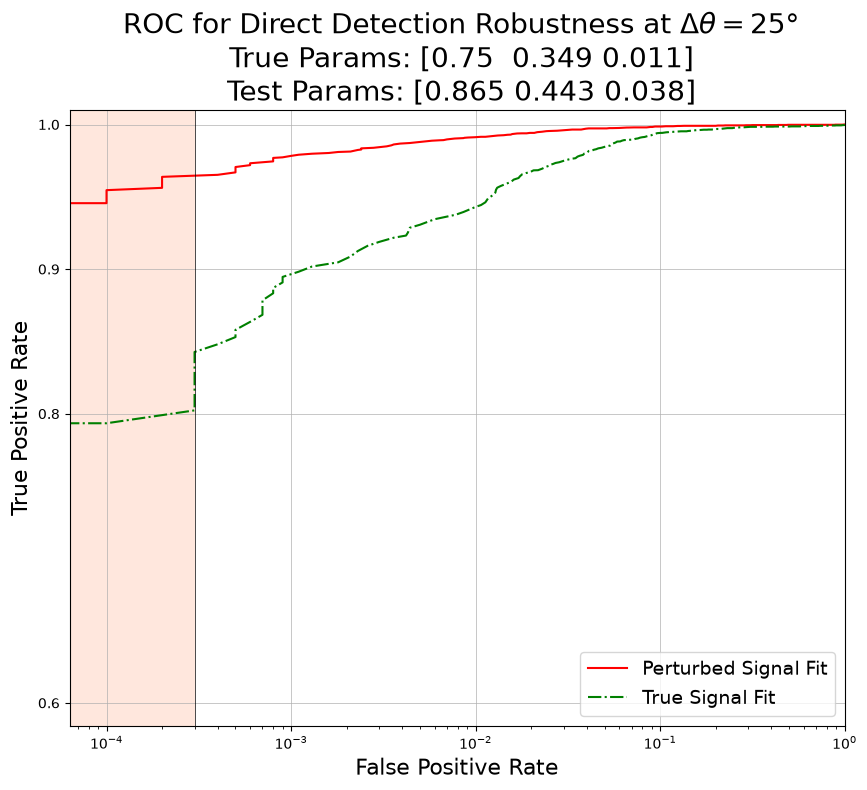

In [ ]:
# Generating the ROC curves for the unperturbed and positively perturbed detection limit parameters for the Direct Fitting method at 25 degrees of sky coverage angle, as derived from the deviation in its planet localization across datasets

true_planet = pln_psfs_generation(*direct_true_params)[:,1:5]
direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25 = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, *std_test_params_pos_direct, n_comp = 1, verbose = False, angle = 25)
direct_h1_25_unpert , klip_h1_25_unpert, main_klip_h1_25_unpert, direct_h0_25_unpert, klip_h0_25_unpert, main_klip_h0_25_unpert = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, *direct_true_params, n_comp = 1, verbose = False, angle = 25)
roc_curves_klip_robust(direct_h1_25 , direct_h0_25, direct_h1_25_unpert, direct_h0_25_unpert, true_params = antiklip_true_params, test_params = std_test_params_pos_direct, method="Direct")
plt.show()

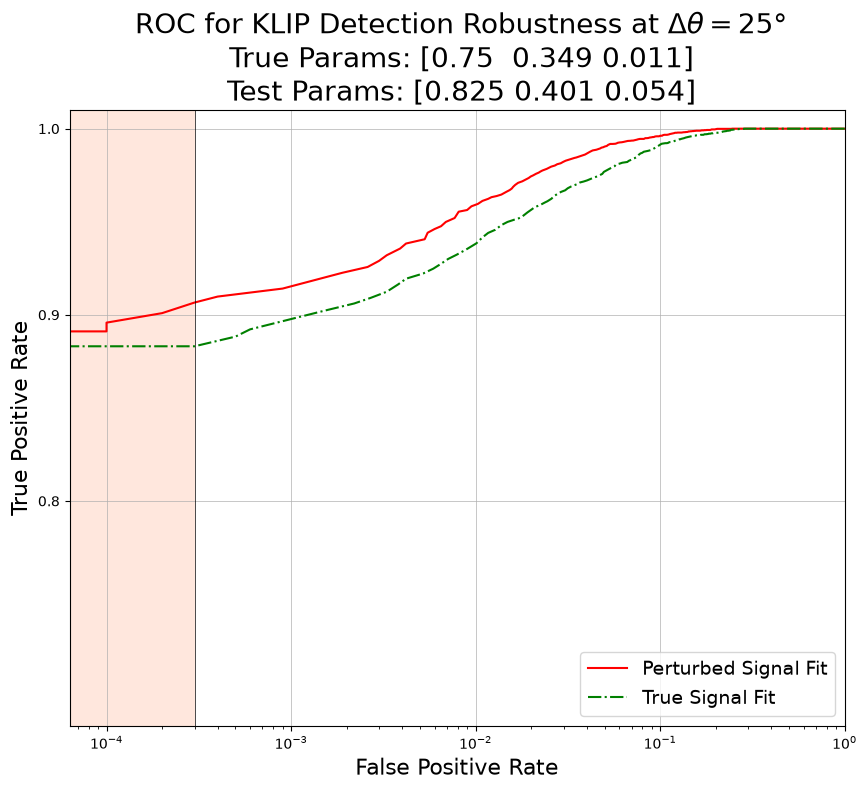

In [ ]:
# Generating the ROC curves for the unperturbed and positively perturbed detection limit parameters for the KLIP Subtraction method at 25 degrees of sky coverage angle, as derived from the deviation in its planet localization across datasets

true_planet = pln_psfs_generation(*klip_true_params)[:,1:5]
direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25 = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, *std_test_params_pos_klip, n_comp = 1, verbose = False, angle = 25)
direct_h1_25_unpert , klip_h1_25_unpert, main_klip_h1_25_unpert, direct_h0_25_unpert, klip_h0_25_unpert, main_klip_h0_25_unpert = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, *klip_true_params, n_comp = 1, verbose = False, angle = 25)
roc_curves_klip_robust(klip_h1_25 , klip_h0_25, klip_h1_25_unpert, klip_h0_25_unpert, true_params = antiklip_true_params, test_params = std_test_params_pos_klip, method="KLIP")
plt.show()

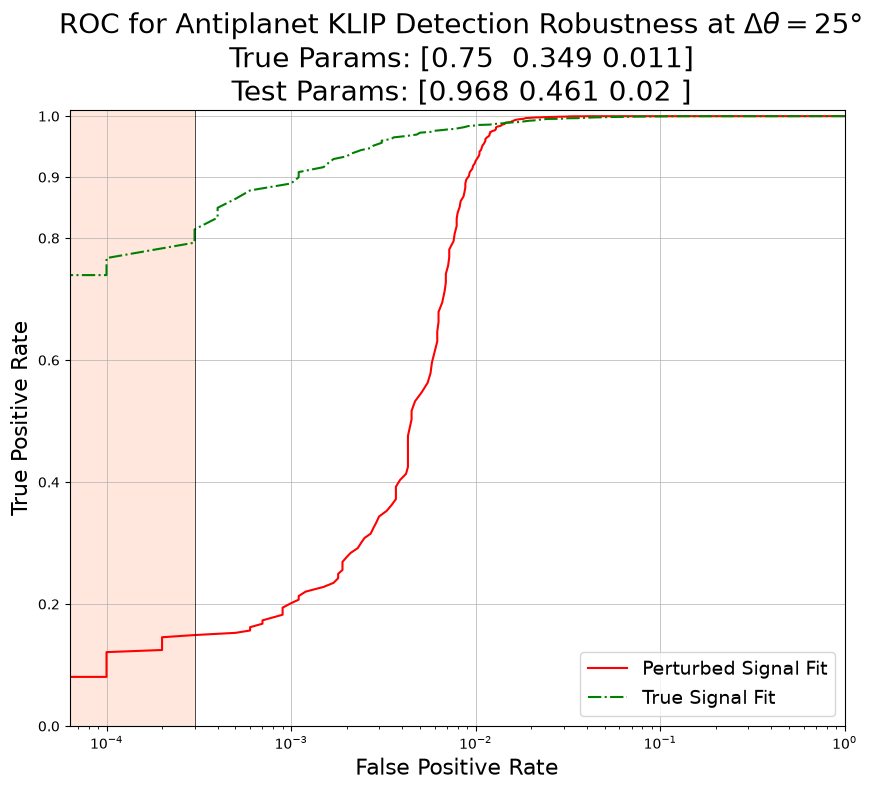

In [186]:
# Generating the ROC curves for the unperturbed and positively perturbed detection limit parameters for the Antiplanet KLIP Subtraction method at 25 degrees of sky coverage angle, as derived from the deviation in its planet localization across datasets

true_planet = pln_psfs_generation(*antiklip_true_params)[:,1:5]
direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25 = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, *std_test_params_pos_antiklip, n_comp = 1, verbose = False, angle = 25)
direct_h1_25_unpert , klip_h1_25_unpert, main_klip_h1_25_unpert, direct_h0_25_unpert, klip_h0_25_unpert, main_klip_h0_25_unpert = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, *antiklip_true_params, n_comp = 1, verbose = False, angle = 25)
roc_curves_klip_robust(main_klip_h1_25 , main_klip_h0_25, main_klip_h1_25_unpert, main_klip_h0_25_unpert, true_params = antiklip_true_params, test_params = std_test_params_pos_antiklip, method="Antiplanet KLIP")
plt.show()

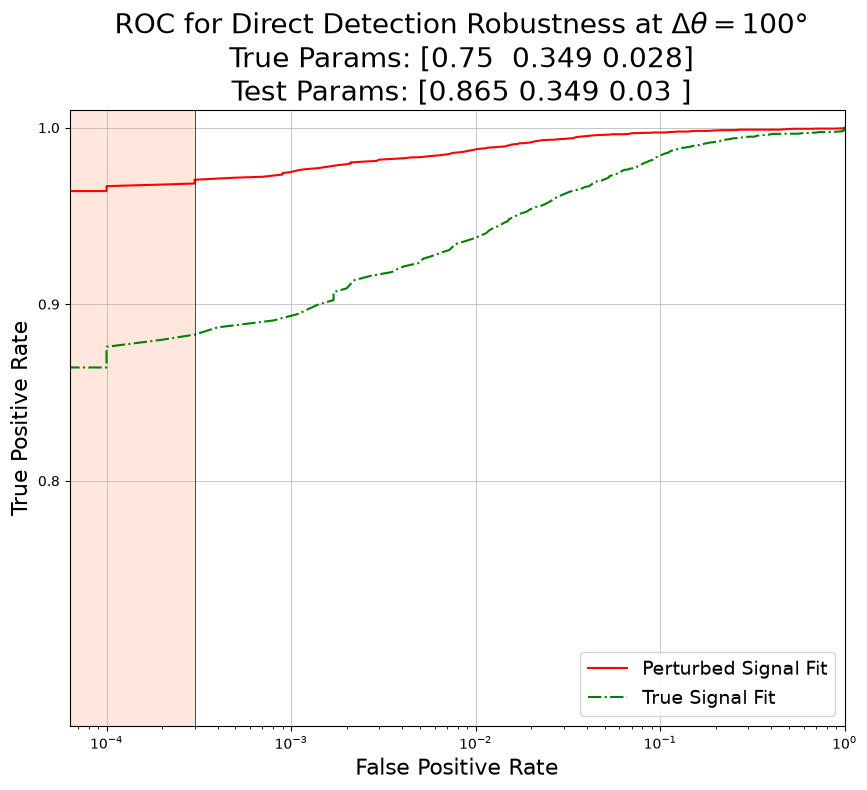

In [ ]:
# Generating the ROC curves for the unperturbed and positively perturbed detection limit parameters for the Direct Fitting method at 100 degrees of sky coverage angle, as derived from the deviation in its planet localization across datasets

true_planet = pln_psfs_generation_100(*direct_true_params_100)[:,1:5]
direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100 = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, *std_test_params_pos_direct_100, n_comp = 1, verbose = False, angle = 100)
direct_h1_100_unpert , klip_h1_100_unpert, main_klip_h1_100_unpert, direct_h0_100_unpert, klip_h0_100_unpert, main_klip_h0_100_unpert = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, *direct_true_params_100, n_comp = 1, verbose = False, angle = 100)
roc_curves_klip_robust(direct_h1_100 , direct_h0_100, direct_h1_100_unpert, direct_h0_100_unpert, true_params = direct_true_params_100, test_params = std_test_params_pos_direct_100, method="Direct", sky_coverage=100)
plt.show()

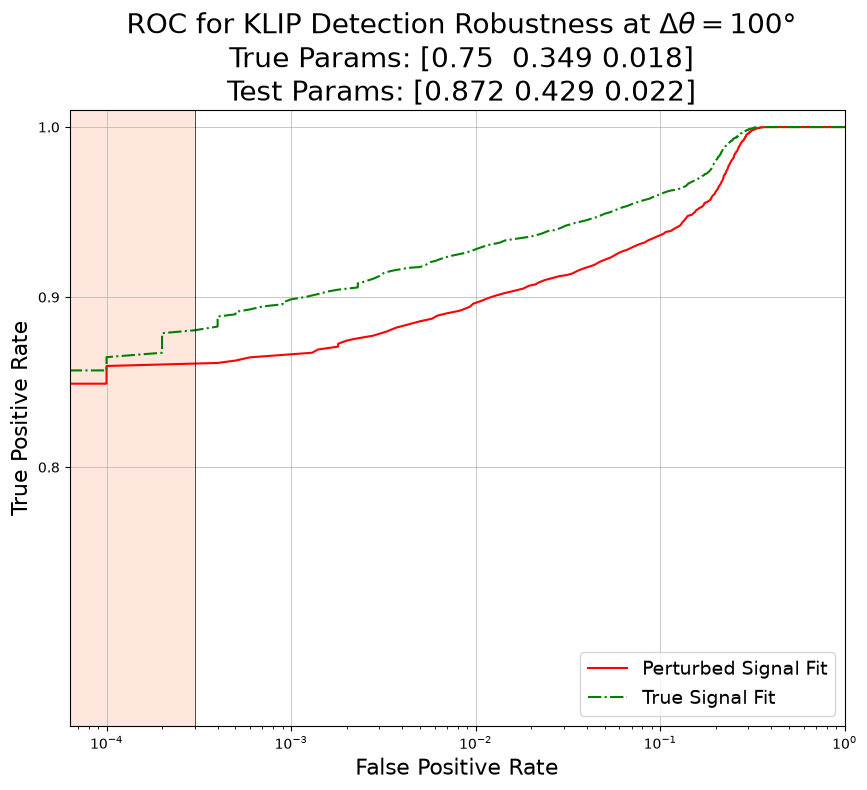

In [ ]:
# Generating the ROC curves for the unperturbed and positively perturbed detection limit parameters for the KLIP Subtraction method at 100 degrees of sky coverage angle, as derived from the deviation in its planet localization across datasets

true_planet = pln_psfs_generation_100(*klip_true_params_100)[:,1:5]
direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100 = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, *std_test_params_pos_klip_100, n_comp = 1, verbose = False, angle = 100)
direct_h1_100_unpert , klip_h1_100_unpert, main_klip_h1_100_unpert, direct_h0_100_unpert, klip_h0_100_unpert, main_klip_h0_100_unpert = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, *klip_true_params_100, n_comp = 1, verbose = False, angle = 100)
roc_curves_klip_robust(klip_h1_100 , klip_h0_100, klip_h1_100_unpert, klip_h0_100_unpert, true_params = klip_true_params_100, test_params = std_test_params_pos_klip_100, method="KLIP", sky_coverage=100)
plt.show()

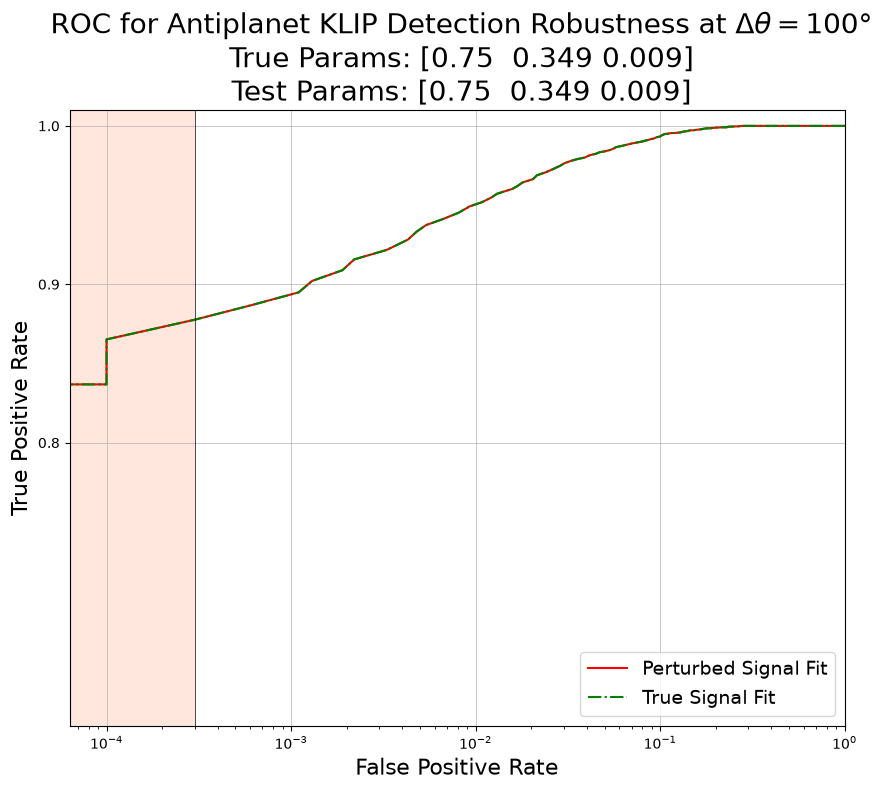

In [189]:
# Generating the ROC curves for the unperturbed and positively perturbed detection limit parameters for the Antiplanet KLIP Subtraction method at 100 degrees of sky coverage angle, as derived from the deviation in its planet localization across datasets (the Antiplanet KLIP Subtraction has perfect localization for all datasets here). 

true_planet = pln_psfs_generation_100(*antiklip_true_params_100)[:,1:5]
direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100 = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, *std_test_params_pos_antiklip_100, n_comp = 1, verbose = False, angle = 100)
direct_h1_100_unpert , klip_h1_100_unpert, main_klip_h1_100_unpert, direct_h0_100_unpert, klip_h0_100_unpert, main_klip_h0_100_unpert = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, *antiklip_true_params_100, n_comp = 1, verbose = False, angle = 100)
roc_curves_klip_robust(main_klip_h1_100 , main_klip_h0_100, main_klip_h1_100_unpert, main_klip_h0_100_unpert, true_params = antiklip_true_params_100, test_params = std_test_params_pos_antiklip_100, method="Antiplanet KLIP", sky_coverage=100)
plt.show()

Fig 9

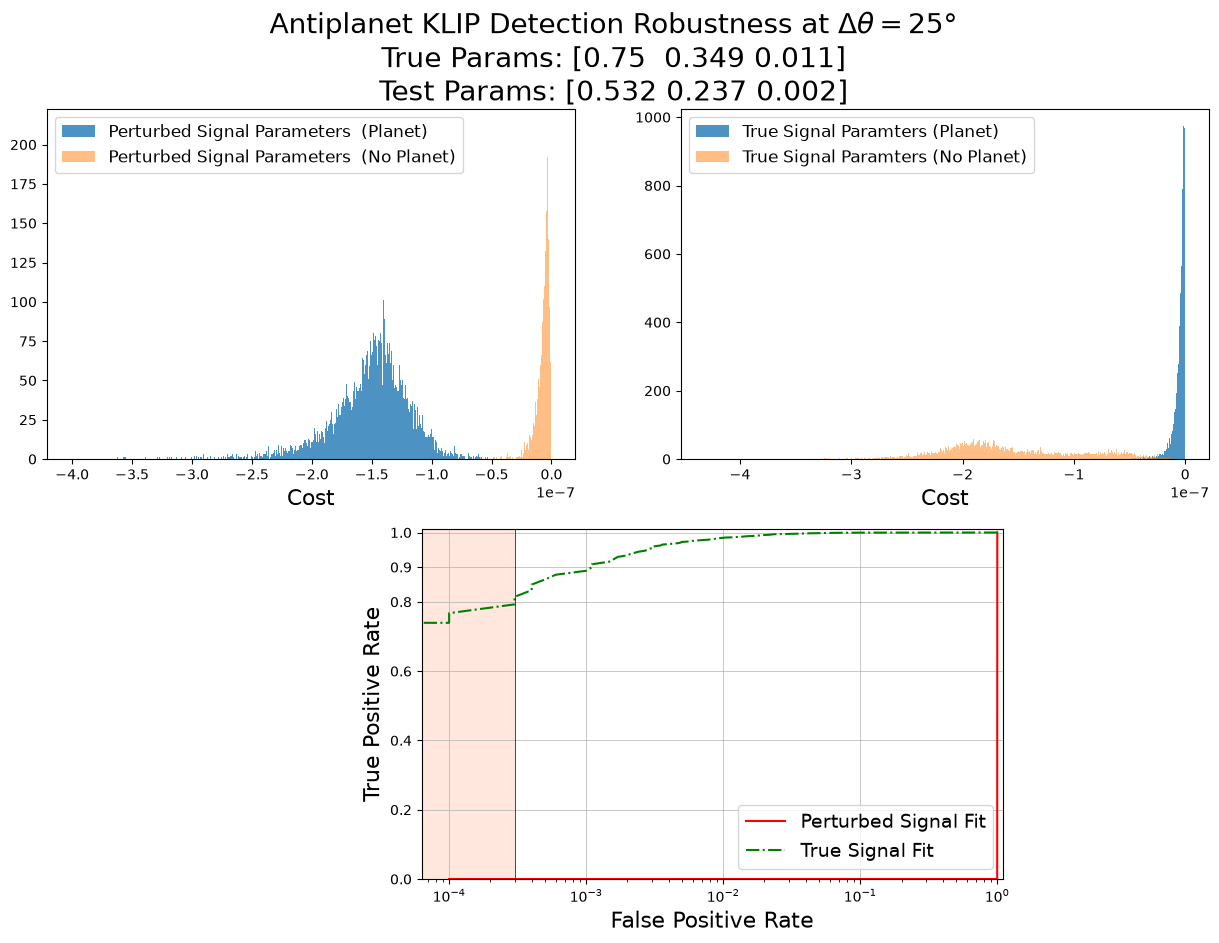

In [190]:
# Generating the ROC curves for the unperturbed and negatively perturbed detection limit parameters for the Antiplanet KLIP Subtraction method at 25 degrees of sky coverage angle, as derived from the deviation in its planet localization across datasets. The ROC indicates a bad fit at this low FR. 


true_planet = pln_psfs_generation(*antiklip_true_params)[:,1:5]
direct_h1_25 , klip_h1_25, main_klip_h1_25, direct_h0_25, klip_h0_25, main_klip_h0_25 = monte_carlo_klip(pln_psfs_star_mc_ez, true_planet, *std_test_params_neg_antiklip, n_comp = 1, verbose = False, angle = 25)
detection_plots_klip_robust(main_klip_h1_25 , main_klip_h0_25, main_klip_h1_25_unpert, main_klip_h0_25_unpert, true_params = antiklip_true_params, test_params = std_test_params_neg_antiklip, method="Antiplanet KLIP", plot_all = True, xlim_right = 1.1, )
plt.show()

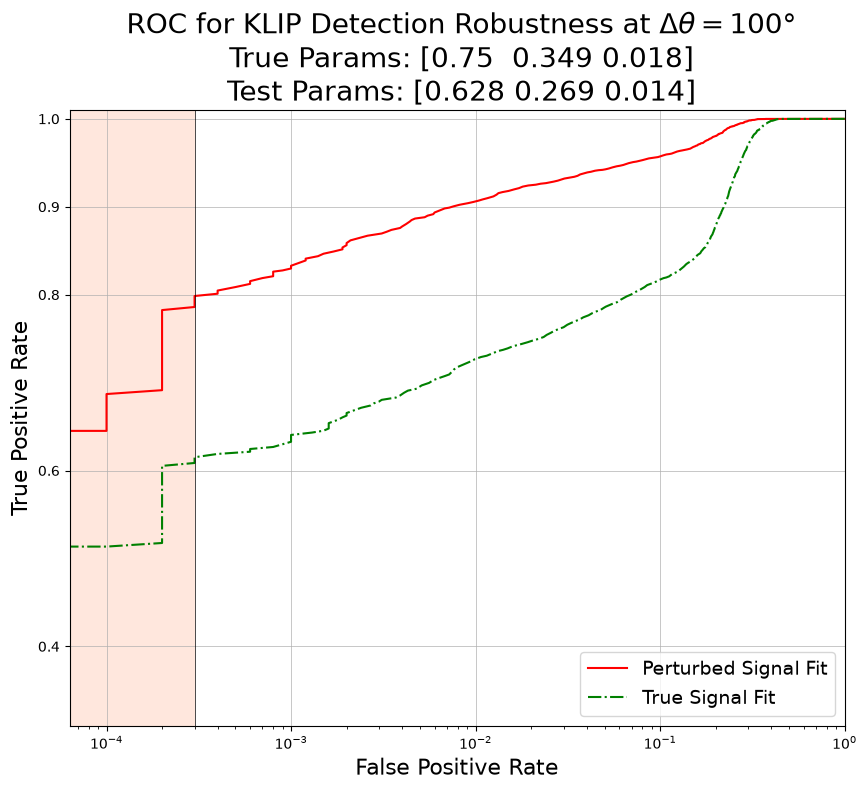

In [191]:
# Generating the ROC curves for the unperturbed and negatively perturbed detection limit parameters for the KLIP Subtraction method at 100 degrees of sky coverage angle, as derived from the deviation in its planet localization across datasets

true_planet = pln_psfs_generation_100(*klip_true_params_100)[:,1:5]
direct_h1_100 , klip_h1_100, main_klip_h1_100, direct_h0_100, klip_h0_100, main_klip_h0_100 = monte_carlo_klip(pln_psfs_star_errs_100_mc_ez, true_planet, *std_test_params_neg_klip_100, n_comp = 1, verbose = False, angle = 100)
roc_curves_klip_robust(klip_h1_100 , klip_h0_100, klip_h1_100_unpert, klip_h0_100_unpert, true_params = klip_true_params_100, test_params = std_test_params_neg_klip_100, method="KLIP", sky_coverage=100)
plt.show()

<h4> Appendix A : Post-Processing the Data from a Spectrally Dispersed PLN

In [100]:
# Loading simulated data for wavelength based stellar aberrations and the corresponding wavelengths. 
# The dataset is still spaced at 1.25 degrees per frame and goes upto 400 degrees of sky coverage. Subsetting 0:80 frames like before makes a dataset with sky coverage 100 degrees. 

star_multiwavels =  np.load("data/multiwavel_data/pln_star_multiwavel_5_datasets.npy")
pln_wavels = np.load("data/multiwavel_data/pln_wavels.npy")
star_multiwavels_100_deg = star_multiwavels[:,0:80,:,1:5]

In [105]:
def direct_fit_multiwavel(params, wavels, actual_psf):
    # Function to compute the direct fit cost function for a multi-wavelength dataset at 25 degrees of sky coverage. 
    # Here the actual_psf has shape (n_frames, n_wavels*pln_modes).
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((20, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel 
    planet_hat_multiwavel_frs = FR_hats[:, np.newaxis, np.newaxis] * planet_hat_multiwavel
    return ((((actual_psf-planet_hat_multiwavel_frs)))**2).mean(axis = (1,2))


def klip_sub_multiwavel(params,wavels, actual_psf, n_comp = 1):
    # Function to compute the KLIP subtraction cost function for a multi-wavelength dataset at 25 degrees of sky coverage. 
    # Here the actual psf has shape (n_frames, n_wavels*pln_modes)
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((20, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel     
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    all_comps = np.zeros((N, n_comp, actual_psf.shape[1]))
    for ang in range (0,N):
        reference_psfs = np.delete(actual_psf, ang, axis=0)
        target_psf = actual_psf[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]  
        all_comps[ang] = components
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    fwms_klip = forward_model_klip(planet_hat_multiwavel, all_comps)
    fwms_klip_frs = FR_hats[:, np.newaxis, np.newaxis] * fwms_klip
    return (((actual_psf-I_star_hat - fwms_klip_frs))**2).mean(axis = (1,2)) 

def main_klip_sub_multiwavel(params,wavels, actual_psf, n_comp = 1):
    # Function to compute the Antiplanet KLIP Subtraction cost function for a multi-wavelength dataset at 25 degrees of sky coverage. 
    # Here the actual_psf has shape (n_frames, n_wavels*pln_modes).
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((20, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel  
    planet_hat_multiwavel_frs = FR_hats[:, np.newaxis, np.newaxis] * planet_hat_multiwavel   
    I_stellars_hat_FRs = actual_psf - planet_hat_multiwavel_frs
    I_star_hat_FRs = np.zeros_like(I_stellars_hat_FRs)
    N = actual_psf.shape[0]
    for ifr in range (0, len(FR_hats)):
        I_stellars_hat = I_stellars_hat_FRs[ifr]
        for ang in range (0,N):
            reference_psfs = np.delete(I_stellars_hat, ang, axis=0)
            target_psf = I_stellars_hat[ang]
            U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
            components = Vt[:n_comp]  
            projection = components.T @ (components @ target_psf)
            I_star_hat_FRs[ifr, ang] = projection
    return (((actual_psf-I_star_hat_FRs - planet_hat_multiwavel_frs))**2).mean(axis = (1,2))


def direct_fit_100_multiwavel(params,wavels, actual_psf):
    # Function to compute the direct fit cost function for a multi-wavelength dataset at 100 degrees of sky coverage. 
    # Here the actual_psf has shape (n_frames, n_wavels*pln_modes).
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((80, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation_100(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel 
    planet_hat_multiwavel_frs = FR_hats[:, np.newaxis, np.newaxis] * planet_hat_multiwavel
    return ((((actual_psf-planet_hat_multiwavel_frs)))**2).mean(axis = (1,2))



def klip_sub_100_multiwavel(params, wavels,actual_psf, n_comp = 1):
    # Function to compute the KLIP subtraction cost function for a multi-wavelength dataset at 100 degrees of sky coverage. 
    # Here the actual psf has shape (n_frames, n_wavels*pln_modes)
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((80, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation_100(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel     
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    all_comps = np.zeros((N, n_comp, actual_psf.shape[1]))
    S_max = []
    for ang in range (0,N):
        reference_psfs = np.delete(actual_psf, ang, axis=0)
        target_psf = actual_psf[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        if ang%10 == 0:
            S_norm = S / np.sum(S)
            S_max.append(S_norm[:2])
        components = Vt[:n_comp]  
        all_comps[ang] = components
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    fwms_klip = forward_model_klip(planet_hat_multiwavel, all_comps)
    fwms_klip_frs = FR_hats[:, np.newaxis, np.newaxis] * fwms_klip
    return ((((actual_psf-I_star_hat - fwms_klip_frs))**2).mean(axis = (1,2)), I_star_hat, S_max)

def main_klip_sub_100_multiwavel(params, wavels, actual_psf, n_comp = 1):
    # Function to compute the Antiplanet KLIP Subtraction cost function for a multi-wavelength dataset at 100 degrees of sky coverage. 
    # Here the actual_psf has shape (n_frames, n_wavels*pln_modes).
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((80, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation_100(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel  
    planet_hat_multiwavel_frs = FR_hats[:, np.newaxis, np.newaxis] * planet_hat_multiwavel   
    I_stellars_hat_FRs = actual_psf - planet_hat_multiwavel_frs
    I_star_hat_FRs = np.zeros_like(I_stellars_hat_FRs)
    N = actual_psf.shape[0]
    S_max = []
    for ifr in range (0, len(FR_hats)):
        I_stellars_hat = I_stellars_hat_FRs[ifr]
        for ang in range (0,N):
            reference_psfs = np.delete(I_stellars_hat, ang, axis=0)
            target_psf = I_stellars_hat[ang]
            U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
            if ang%10 == 0:
                 S_norm = S / np.sum(S)
                 S_max.append(S_norm[:2])
            components = Vt[:n_comp]  
            projection = components.T @ (components @ target_psf)
            I_star_hat_FRs[ifr, ang] = projection
    return ((((actual_psf-I_star_hat_FRs - planet_hat_multiwavel_frs))**2).mean(axis = (1,2)), I_star_hat_FRs,S_max)


def direct_fit_150_multiwavel(params, wavels,actual_psf):
    # Function to compute the direct fit cost function for a multi-wavelength dataset at 150 degrees of sky coverage. 
    # Here the actual_psf has shape (n_frames, n_wavels*pln_modes).
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((120, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation_wider(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel 
    planet_hat_multiwavel_frs = FR_hats[:, np.newaxis, np.newaxis] * planet_hat_multiwavel
    return ((((actual_psf-planet_hat_multiwavel_frs)))**2).mean(axis = (1,2))

def klip_sub_150_multiwavel(params, wavels,actual_psf, n_comp = 1):
    # Function to compute the KLIP subtraction cost function for a multi-wavelength dataset at 150 degrees of sky coverage. 
    # Here the actual psf has shape (n_frames, n_wavels*pln_modes)
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((120, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation_wider(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel     
    I_star_hat = np.zeros_like(actual_psf)
    N = actual_psf.shape[0]
    all_comps = np.zeros((N, n_comp, actual_psf.shape[1]))
    for ang in range (0,N):
        reference_psfs = np.delete(actual_psf, ang, axis=0)
        target_psf = actual_psf[ang]
        U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
        components = Vt[:n_comp]  
        all_comps[ang] = components
        projection = components.T @ (components @ target_psf)
        I_star_hat[ang] = projection
    fwms_klip = forward_model_klip(planet_hat_multiwavel, all_comps)
    fwms_klip_frs = FR_hats[:, np.newaxis, np.newaxis] * fwms_klip
    return (((actual_psf-I_star_hat - fwms_klip_frs))**2).mean(axis = (1,2))

def main_klip_sub_150_multiwavel(params, wavels,actual_psf, n_comp = 1):
    # Function to compute the Antiplanet KLIP Subtraction cost function for a multi-wavelength dataset at 150 degrees of sky coverage. 
    # Here the actual_psf has shape (n_frames, n_wavels*pln_modes).
    r_hat , theta_hat, FR_hats = params
    planet_hat_multiwavel = np.zeros((120, len(wavels)*4))
    for iw, w in enumerate(wavels):
            wavel_sep = r_hat/w
            planet_psf_wavel = pln_psfs_generation_wider(wavel_sep, theta_hat)[:,1:5]
            planet_hat_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel  
    planet_hat_multiwavel_frs = FR_hats[:, np.newaxis, np.newaxis] * planet_hat_multiwavel   
    I_stellars_hat_FRs = actual_psf - planet_hat_multiwavel_frs
    I_star_hat_FRs = np.zeros_like(I_stellars_hat_FRs)
    N = actual_psf.shape[0]
    for ifr in range (0, len(FR_hats)):
        I_stellars_hat = I_stellars_hat_FRs[ifr]
        for ang in range (0,N):
            reference_psfs = np.delete(I_stellars_hat, ang, axis=0)
            target_psf = I_stellars_hat[ang]
            U, S, Vt = np.linalg.svd(reference_psfs, full_matrices=False) 
            components = Vt[:n_comp]  
            projection = components.T @ (components @ target_psf)
            I_star_hat_FRs[ifr, ang] = projection
    return (((actual_psf-I_star_hat_FRs - planet_hat_multiwavel_frs))**2).mean(axis = (1,2))

def direct_fit_tuning_multiwavel(planet, star_psf, test_seps, test_thetas, test_frs, wavels, hund= False, hund_fif = False):
    # Function to evaluate the direct fit cost across the parameter space of separations, angles and FRs for a multi-wavelength dataset at a given sky coverage. 
    # Function returns the minimum cost parameters, the cost array and the actual psfs for each parameter combination.
    costs_pln_planet = np.zeros((len(test_seps), len(test_thetas), len(test_frs)))
    actual_psfs = []
    for isep, sep in enumerate(test_seps):
        for ithet, thet in enumerate(test_thetas):
            if hund:
                actual_pln_psf = star_psf.reshape(80,400)+ planet
                cost_val_frs= direct_fit_100_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf)
                actual_psfs.append(actual_pln_psf)
            elif hund_fif:
                actual_pln_psf = star_psf.reshape(120,400)+ planet
                cost_val_frs= direct_fit_150_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf)
            else:
                actual_pln_psf = star_psf.reshape(20,400)+ planet
                cost_val_frs= direct_fit_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf)
            costs_pln_planet[isep, ithet] = cost_val_frs
    min_index_flat = np.argmin(costs_pln_planet)
    min_index_3d = np.unravel_index(min_index_flat, costs_pln_planet.shape)
    final_min_params = np.array([test_seps[min_index_3d[0]], test_thetas[min_index_3d[1]], test_frs[min_index_3d[2]]])
    return (final_min_params, costs_pln_planet, actual_psfs)


def klip_sub_tuning_multiwavel(planet, star_psf, test_seps, test_thetas, test_frs, wavels, hund = False, hund_fif = False, ncomp  = 1):
    # Function to evaluate the KLIP Subtraction cost across the parameter space of separations, angles and FRs for a multi-wavelength dataset at a given sky coverage.
    # Function returns the minimum cost parameters, the cost array the stellar estimates, and a list of the largest two normalized singular values at every frame spaced 10 degrees apart for each parameter combination.
    costs_pln_planet = np.zeros((len(test_seps), len(test_thetas), len(test_frs)))    
    S_maxs = []
    Stellar_esimates = []
    for isep, sep in enumerate(test_seps):
        for ithet, thet in enumerate(test_thetas):
            if hund:
                actual_pln_psf = star_psf.reshape(80,400)+ planet
                cost_val_frs, stellar_estimate, S_max= klip_sub_100_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf, n_comp  = ncomp)
                S_maxs.append(S_max)
                Stellar_esimates.append(stellar_estimate)
            elif hund_fif:
                actual_pln_psf = star_psf.reshape(120,400)+ planet
                cost_val_frs= klip_sub_150_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf, n_comp  = ncomp)
            else:
                actual_pln_psf = star_psf.reshape(20,400)+ planet
                cost_val_frs= klip_sub_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf, n_comp  = ncomp)
            costs_pln_planet[isep, ithet] = cost_val_frs
    min_index_flat = np.argmin(costs_pln_planet)
    min_index_3d = np.unravel_index(min_index_flat, costs_pln_planet.shape)
    final_min_params = np.array([test_seps[min_index_3d[0]], test_thetas[min_index_3d[1]], test_frs[min_index_3d[2]]])
    return (final_min_params, costs_pln_planet, Stellar_esimates, S_maxs)

def main_klip_sub_tuning_multiwavel(planet, star_psf, test_seps, test_thetas, test_frs, wavels, hund = False, hund_fif = False, ncomp = 1):
    # Function to evaluate the Antiplanet KLIP Subtraction cost across the parameter space of separations, angles and FRs for a multi-wavelength dataset at a given sky coverage.
    # Function returns the minimum cost parameters, the cost array the stellar estimates, and a list of the largest two normalized singular values at every frame spaced 10 degrees apart for each parameter combination.
    costs_pln_planet = np.zeros((len(test_seps), len(test_thetas), len(test_frs)))
    S_maxs = []
    Stellar_esimates = []
    for isep, sep in enumerate(test_seps):
        for ithet, thet in enumerate(test_thetas):
            if hund:
                actual_pln_psf= star_psf.reshape(80,400)+ planet
                cost_val_frs, stellar_estimate, S_max= main_klip_sub_100_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf, n_comp = ncomp)
                S_maxs.append(S_max)
                Stellar_esimates.append(stellar_estimate)

            elif hund_fif:
                actual_pln_psf = star_psf.reshape(120,400)+ planet
                cost_val_frs= main_klip_sub_150_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf, n_comp = ncomp)
            else:
                actual_pln_psf = star_psf.reshape(20,400)+ planet
                cost_val_frs= main_klip_sub_multiwavel((sep, thet, test_frs), wavels,actual_pln_psf, n_comp = ncomp)
            costs_pln_planet[isep, ithet] = cost_val_frs
    min_index_flat = np.argmin(costs_pln_planet)
    min_index_3d = np.unravel_index(min_index_flat, costs_pln_planet.shape)
    final_min_params = np.array([test_seps[min_index_3d[0]], test_thetas[min_index_3d[1]], test_frs[min_index_3d[2]]])
    return (final_min_params, costs_pln_planet, Stellar_esimates, S_maxs)

def localization_arrays_multiwavel(data_theta, data_fr, test_FRs, method, coverage,
                        data_sep = 0.75, test_seps = np.arange(0,2.25,0.25), 
                        test_thetas = np.linspace(0,np.pi, 19, endpoint=True), 
                        big_dataset = star_multiwavels_100_deg, n_datasets = 5, wavelength = pln_wavels, ncomp = 1, dataset_start = 0, verbose = True):
    # Function for doing the localization for every dataset of the multi-wavelength dataset at a given sky coverage. 
    # The function returns the cost array, costs of the correct paramters, lowest cost in the grid, minimum cost parameters, the stellar estimates and the largest two normalized singular values at every frame spaced 10 degrees apart for each parameter combination for each dataset.
    if coverage == 25:
        planet_psfs_multiwavel = np.zeros((20,len(wavelength)*4))
        for iw, w in enumerate(wavelength):
            wavel_sep = data_sep/w
            planet_psf_wavel = pln_psfs_generation(wavel_sep, data_theta, data_fr)[:,1:5]
            planet_psfs_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel
    elif coverage == 100:
        planet_psfs_multiwavel = np.zeros((80,len(wavelength)*4))
        for iw, w in enumerate(wavelength):
            wavel_sep = data_sep/w
            planet_psf_wavel = pln_psfs_generation_100(wavel_sep, data_theta, data_fr)[:,1:5]
            planet_psfs_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel   
    elif coverage == 150:
        planet_psfs_multiwavel = np.zeros((120,len(wavelength)*4))
        for iw, w in enumerate(wavelength):
            wavel_sep = data_sep/w
            planet_psf_wavel = pln_psfs_generation_wider(wavel_sep, data_theta, data_fr)[:,1:5]
            planet_psfs_multiwavel[:,iw*4:(iw+1)*4] = planet_psf_wavel   
    
    datasets = big_dataset[dataset_start:dataset_start+n_datasets]
    min_detlim = np.zeros((len(datasets), 3))
    cost_pln_detlim = np.zeros((len(datasets), len(test_seps), len(test_thetas), len(test_FRs)))
    S_maxs_ids  = []
    Stellar_estimates_ids = []
    for id, d in enumerate (datasets):
        if verbose:
            print(f"Now on Datset : {id}")
        if method == "direct":
            if coverage == 25:
                min_detlim[id], cost_pln_detlim[id] = direct_fit_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                        test_thetas, test_FRs, wavels = wavelength)
            elif coverage == 100:
                min_detlim[id], cost_pln_detlim[id], actual_psfs_id = direct_fit_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                                   test_thetas, test_FRs, hund = True, wavels = wavelength)
                Stellar_estimates_ids.append(actual_psfs_id)   
            elif coverage == 150:
                min_detlim[id], cost_pln_detlim[id] = direct_fit_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund_fif = True, wavels = wavelength)
            else:
                raise ValueError("Wrong coverage value")
        
        elif method == "klip":
            if coverage == 25:
                min_detlim[id], cost_pln_detlim[id] = klip_sub_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                        test_thetas, test_FRs, ncomp  = ncomp, wavels = wavelength)
            elif coverage == 100:
                min_detlim[id], cost_pln_detlim[id] , Stellar_estimates_id, S_maxs_id= klip_sub_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund = True, ncomp  = ncomp, wavels = wavelength)
                S_maxs_ids.append(S_maxs_id)
                Stellar_estimates_ids.append(Stellar_estimates_id)
            elif coverage == 150:
                min_detlim[id], cost_pln_detlim[id] = klip_sub_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund_fif = True, ncomp  = ncomp, wavels = wavelength)
            else:
                raise ValueError("Wrong coverage value")
        
        elif method == "klip_antiplanet":
            if coverage == 25:
                min_detlim[id], cost_pln_detlim[id] = main_klip_sub_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                        test_thetas, test_FRs, ncomp  = ncomp, wavels = wavelength)
            elif coverage == 100:
                min_detlim[id], cost_pln_detlim[id], Stellar_estimates_id, S_maxs_id= main_klip_sub_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund = True, ncomp  = ncomp, wavels = wavelength)

                S_maxs_ids.append(S_maxs_id)
                Stellar_estimates_ids.append(Stellar_estimates_id)
            elif coverage == 150:
                min_detlim[id], cost_pln_detlim[id] = main_klip_sub_tuning_multiwavel(planet_psfs_multiwavel, d, test_seps, 
                                                                                        test_thetas, test_FRs, hund_fif = True, ncomp  = ncomp, wavels = wavelength)
            else:
                raise ValueError("Wrong coverage value")
        
        else:
            raise ValueError("Wrong method")
     
    optim_fr = test_FRs[np.argmin(np.abs(test_FRs - data_fr))]
    optim_theta = test_thetas[np.argmin(np.abs(test_thetas - data_theta))]
    optim_costs_detlim= [cost_pln_detlim[i, np.where(test_seps == data_sep)[0][0], np.where(test_thetas == optim_theta)[0][0], 
                                                np.where(test_FRs == optim_fr)[0][0]] for i in range(cost_pln_detlim.shape[0])]
    min_costs_detlim = [np.min(cost_pln_detlim[i]) for i in range(cost_pln_detlim.shape[0])]
    return (cost_pln_detlim, optim_costs_detlim, min_costs_detlim, min_detlim, Stellar_estimates_ids, S_maxs_ids)

In [106]:
# Defines the number of componenets from 1 through 15 to see what the optimal number of components is for the KLIP Subtraction and Antiplanet KLIP Subtraction methods in this high-dimensional spectral space.
ncomps_checking = np.arange(1,15,1)

In [123]:
# Code to run the localization for the Antiplanet KLIP Subtraction method for a multi-wavelength dataset at 100 degrees of sky coverage and a true FR of 0.001. This localization uses the correct parameters as test parameters to test if the stellar estimate matches at the correct n_comp.
final_plot_true_fr = np.array([0.001])
cost_pln_anti_KLIP_100s = []
optim_costs_anti_KLIP_100s = []
min_costs_anti_KLIP_100s = []
min_antiKLIP_100s = []
Stellar_esimtates_antiKLIP_100s= []
S_maxs_antiKLIP_100s = []
for ncomp_test in ncomps_checking:
      cost_pln_anti_KLIP_100, optim_costs_anti_KLIP_100, min_costs_anti_KLIP_100, min_antiKLIP_100, Stellar_esimtates_antiKLIP_100, S_maxs_antiKLIP_100 =\
      localization_arrays_multiwavel(data_theta = np.pi/9, data_fr = 0.001, test_FRs = final_plot_true_fr,
                               method = "klip_antiplanet", coverage = 100,
                        data_sep = 0.75, test_seps = np.array([0.75]), 
                        test_thetas = np.array([np.pi/9]), 
                        big_dataset = star_multiwavels_100_deg, ncomp=ncomp_test, n_datasets = 1, verbose = False)
      cost_pln_anti_KLIP_100s.append(cost_pln_anti_KLIP_100)
      optim_costs_anti_KLIP_100s.append(optim_costs_anti_KLIP_100)
      min_costs_anti_KLIP_100s.append(min_costs_anti_KLIP_100)
      min_antiKLIP_100s.append(min_antiKLIP_100)
      Stellar_esimtates_antiKLIP_100s.append(Stellar_esimtates_antiKLIP_100)
      S_maxs_antiKLIP_100s.append(S_maxs_antiKLIP_100)

Stellar_esimtates_antiKLIP_100s = np.array(Stellar_esimtates_antiKLIP_100s)

In [124]:
# Code to run the localization for the KLIP Subtraction method for a multi-wavelength dataset at 100 degrees of sky coverage and a true FR of 0.001. This localization uses the correct parameters as test parameters to test if the stellar estimate matches at the correct n_comp.

cost_pln_KLIP_100s = []
optim_costs_KLIP_100s = []
min_costs_KLIP_100s = []
min_KLIP_100s = []
Stellar_esimtates_KLIP_100s= []
S_maxs_KLIP_100s = []
for ncomp_test in ncomps_checking:
      cost_pln_KLIP_100, optim_costs_KLIP_100, min_costs_KLIP_100, min_KLIP_100, Stellar_esimtates_KLIP_100, S_maxs_KLIP_100 =\
      localization_arrays_multiwavel(data_theta = np.pi/9, data_fr = 0.001, test_FRs = final_plot_true_fr,
                               method = "klip", coverage = 100,
                        data_sep = 0.75, test_seps = np.array([0.75]), 
                        test_thetas = np.array([np.pi/9]), 
                        big_dataset = star_multiwavels_100_deg, ncomp=ncomp_test, n_datasets = 1, verbose = False)
      cost_pln_KLIP_100s.append(cost_pln_KLIP_100)
      optim_costs_KLIP_100s.append(optim_costs_KLIP_100)
      min_costs_KLIP_100s.append(min_costs_KLIP_100)
      min_KLIP_100s.append(min_KLIP_100)
      Stellar_esimtates_KLIP_100s.append(Stellar_esimtates_KLIP_100)
      S_maxs_KLIP_100s.append(S_maxs_KLIP_100)

Stellar_esimtates_KLIP_100s = np.array(Stellar_esimtates_KLIP_100s)

In [ ]:
# Code to index the stellar estimates such that the dimensions corresponding to singular test parameter and a single dataset are collapsed. The stellar estimate array is then reshaped to have the PLN modes and the wavelengths as separate dimensions. 
# The stellar estimates for the best performing number of components (as we identified from localization of these multiwavelength datasets and by comparing the stellar estimates to the true star) are then averaged across the frames to get a single stellar estimate for each wavelength and PLN mode.

Stellar_esimtates_antiKLIP_100s =  Stellar_esimtates_antiKLIP_100s[:,0,0,0,:,:]
Stellar_esimtates_antiKLIP_100s_wavels = Stellar_esimtates_antiKLIP_100s.reshape(Stellar_esimtates_antiKLIP_100s.shape[0], Stellar_esimtates_antiKLIP_100s.shape[1], 100, 4)

Stellar_esimtates_KLIP_100s = Stellar_esimtates_KLIP_100s[:,0,0,:,:]
Stellar_esimtates_KLIP_100s_wavels = Stellar_esimtates_KLIP_100s.reshape(Stellar_esimtates_KLIP_100s.shape[0], Stellar_esimtates_KLIP_100s.shape[1], 100, 4)

Stellar_esimtate_antiKLIP_100s_wavels_ncomp5 = np.mean(Stellar_esimtates_antiKLIP_100s_wavels[4], axis = 0)
Stellar_esimtate_KLIP_100s_wavels_ncomp1 = np.mean(Stellar_esimtates_KLIP_100s_wavels[0], axis = 0)
true_star = np.mean(star_multiwavels_100_deg[0], axis = 0)

Fig 10

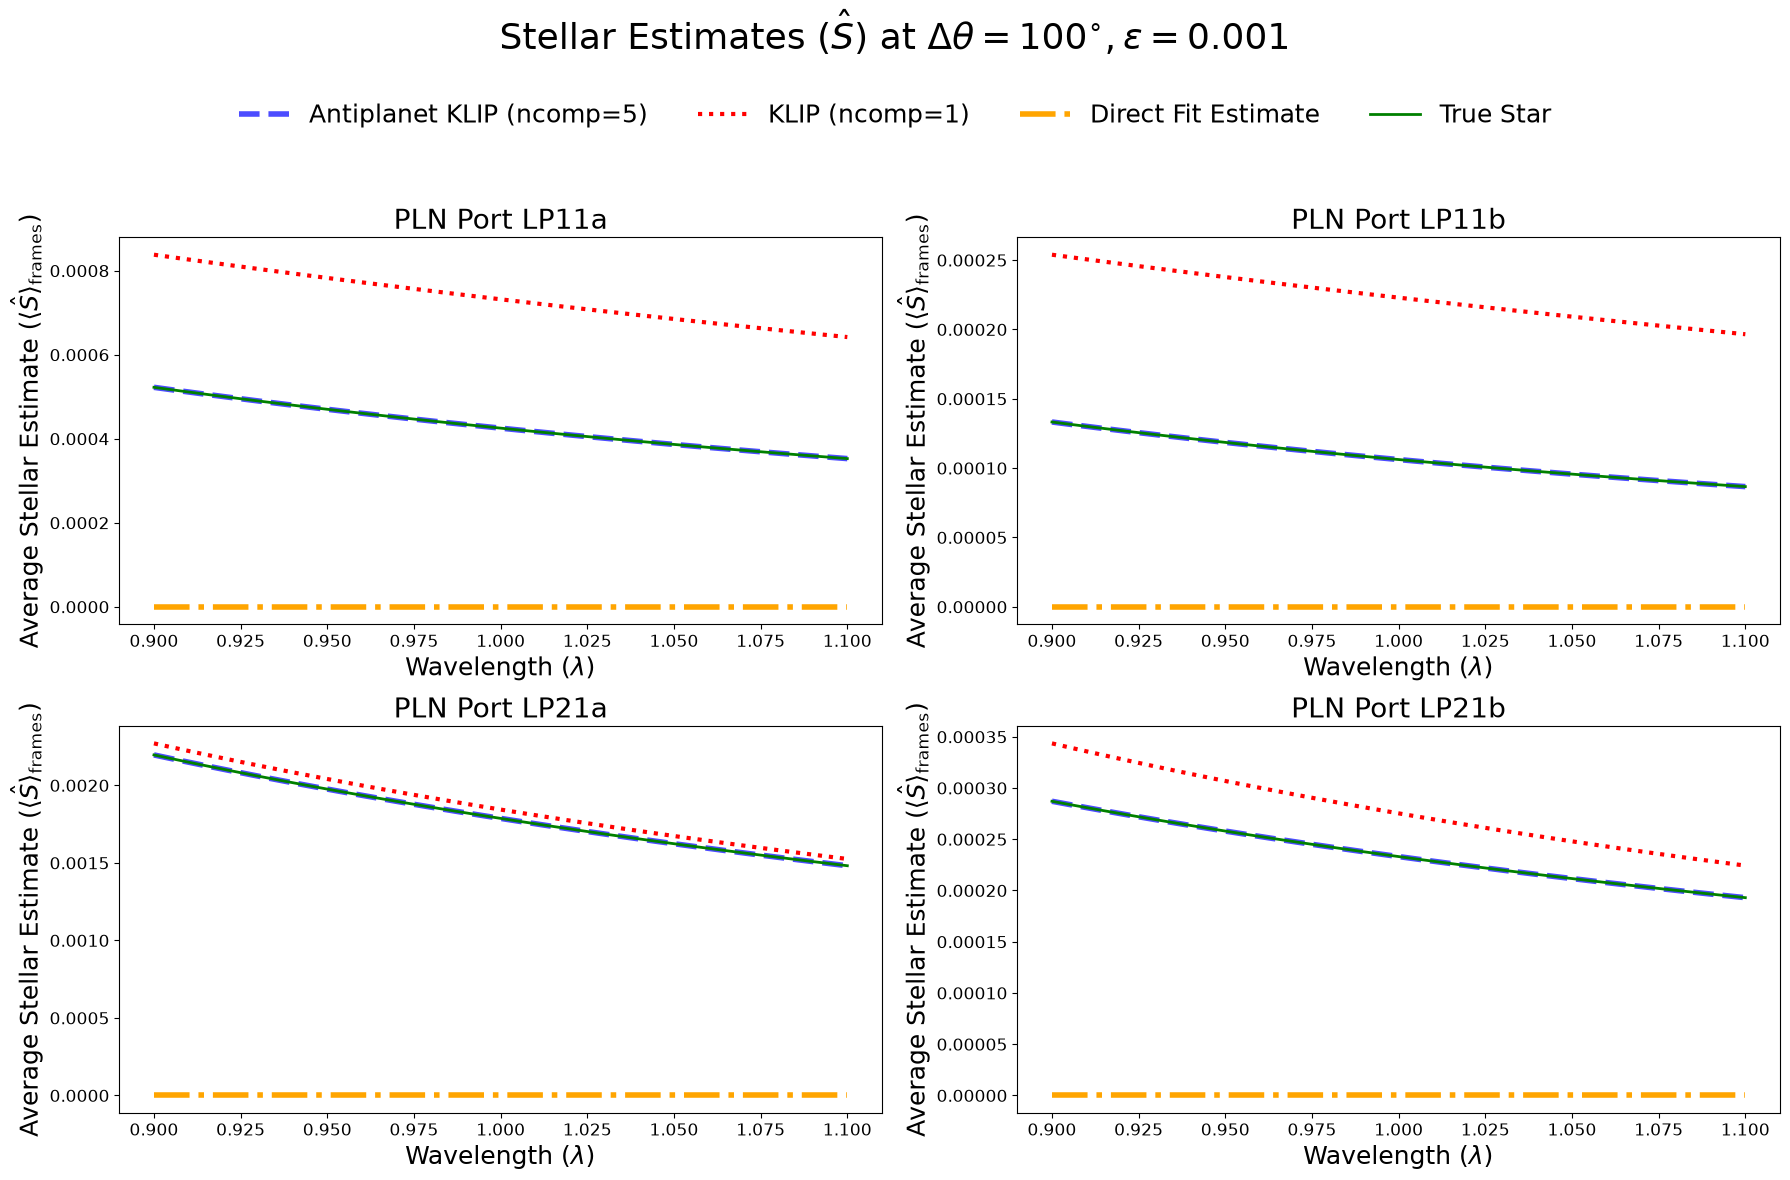

In [130]:
# Code to plot the stellar estimates for the best performing number of components for the KLIP Subtraction and Antiplanet KLIP Subtraction methods against the true star and the direct fit estimate. 
# We plot every PLN mode for the multi-wavelength dataset at 100 degrees of sky coverage and a true FR of 0.001, as intensity of stellar estimate vs wavelength.

ports = ["LP11a", "LP11b", "LP21a", "LP21b"]
fig, axs = plt.subplots(2,2, figsize = (18,12))
axs = axs.flatten()

for port in range(1,5):
    axs[port-1].plot(pln_wavels, Stellar_esimtate_antiKLIP_100s_wavels_ncomp5[:,port-1], label = "Antiplanet KLIP (ncomp=5)", ls = "--", c = "b", lw = 4, alpha =  0.7)
    axs[port-1].plot(pln_wavels, Stellar_esimtate_KLIP_100s_wavels_ncomp1[:,port-1], label = "KLIP (ncomp=1)", ls = ":", c= "r", lw = 3)
    axs[port-1].plot(pln_wavels, np.zeros_like(pln_wavels), label = "Direct Fit Estimate", ls = "-.", c = "orange", lw = 4)
    axs[port-1].plot(pln_wavels, true_star[:,port-1], label = "True Star", c = "green", lw = 2)
    axs[port-1].set_title(f"PLN Port {ports[port-1]}", fontsize = 20)
    axs[port-1].set_xlabel(r"Wavelength ($\lambda$)", fontsize = 18)
    axs[port-1].set_ylabel(r"Average Stellar Estimate ($\langle \hat{S} \rangle_{\text{frames}}$)", fontsize = 18)
    axs[port-1].tick_params(axis='both', labelsize=12)  

handles, labels = axs[0].get_legend_handles_labels() 
fig.legend(handles, labels, loc="upper center", fontsize=18, ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.92))
fig.suptitle(r"Stellar Estimates $(\hat S)$ at $\Delta \theta = 100^{\circ}, \epsilon = 0.001$", fontsize=26)
plt.tight_layout(rect=[0, 0, 1, 0.88])  
plt.show()


<h4> Appendix B: </h4>

 Localization for $\Delta \theta = {100^{\circ}, 150^{\circ}}$

Like Sec 4.2 Fig 7, note below that the argument `dataset_id_title` differs from the argument `data_id` due to the same reason as the one stated there. While the localization code is provided, it would be easier (and faster) to utilize the localization cost arrays saved and provided in the Zenodo release of this repository. 

Fig 11

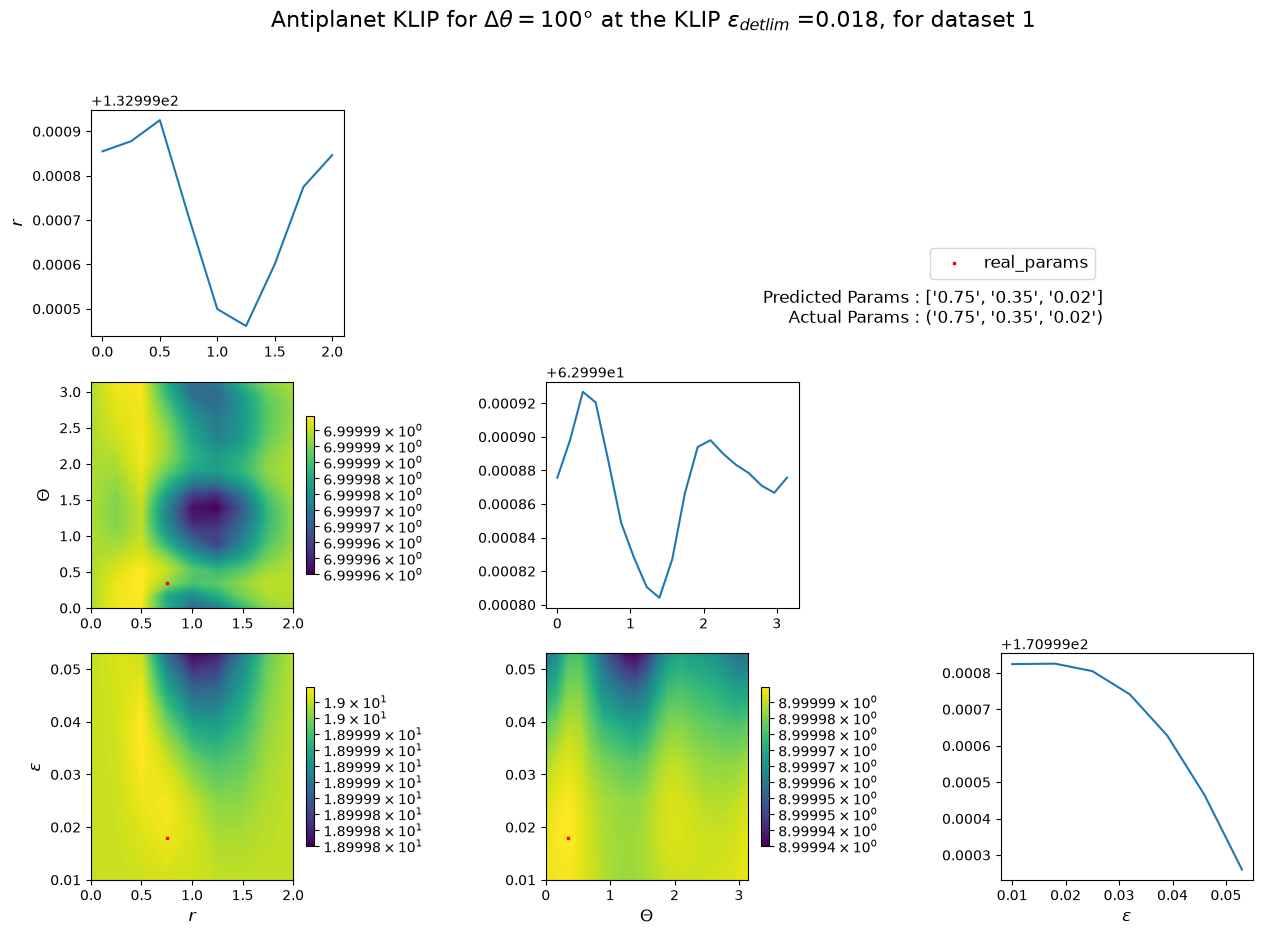

In [ ]:
# Code to perform localization using the Antiplanet KLIP Subtraction method for a dataset with 100 degrees of sky coverage angle, a separation of 0.75, a theta of pi/9, and a flux ratio of 0.018 (the KLIP Subtraction detection limit for 100 degree sky coverage). 
# The code generates the cost grid and creates corner plots to visualize the joint and marginal probability distributions of the localization parameters.

KLIP_detlim_test_FRS_100 = np.array([0.01, 0.018, 0.025, 0.032, 0.039, 0.046, 0.053])
cost_pln_KLIP_detlim_anti_KLIP_100, optim_costs_KLIP_detlim_anti_KLIP_100, min_costs_KLIP_detlim_anti_KLIP_100, min_antiKLIP_KLIP_100 = localization_arrays(data_theta = np.pi/9, data_fr = 0.018, test_FRs = KLIP_detlim_test_FRS_100,
                     method = "klip_antiplanet"  , coverage = 100,
                        data_sep = 0.75, test_seps = np.arange(0,2.25,0.25), 
                        test_thetas = test_thetas, 
                        big_dataset = pln_psfs_star_errs_100_mc_ez[1][np.newaxis, :], verbose = False)
corner_plots(cost_pln_KLIP_detlim_anti_KLIP_100,  0.018, 100, np.arange(0,2.25,0.25),
    test_thetas, KLIP_detlim_test_FRS_100, "Antiplanet KLIP", "KLIP", (0.75, np.pi/9, 0.018),
    pred_mins = True, pred_mins_avgd= min_antiKLIP_KLIP_100[0], data_id = 0, dataset_id_title=1)

Fig 12

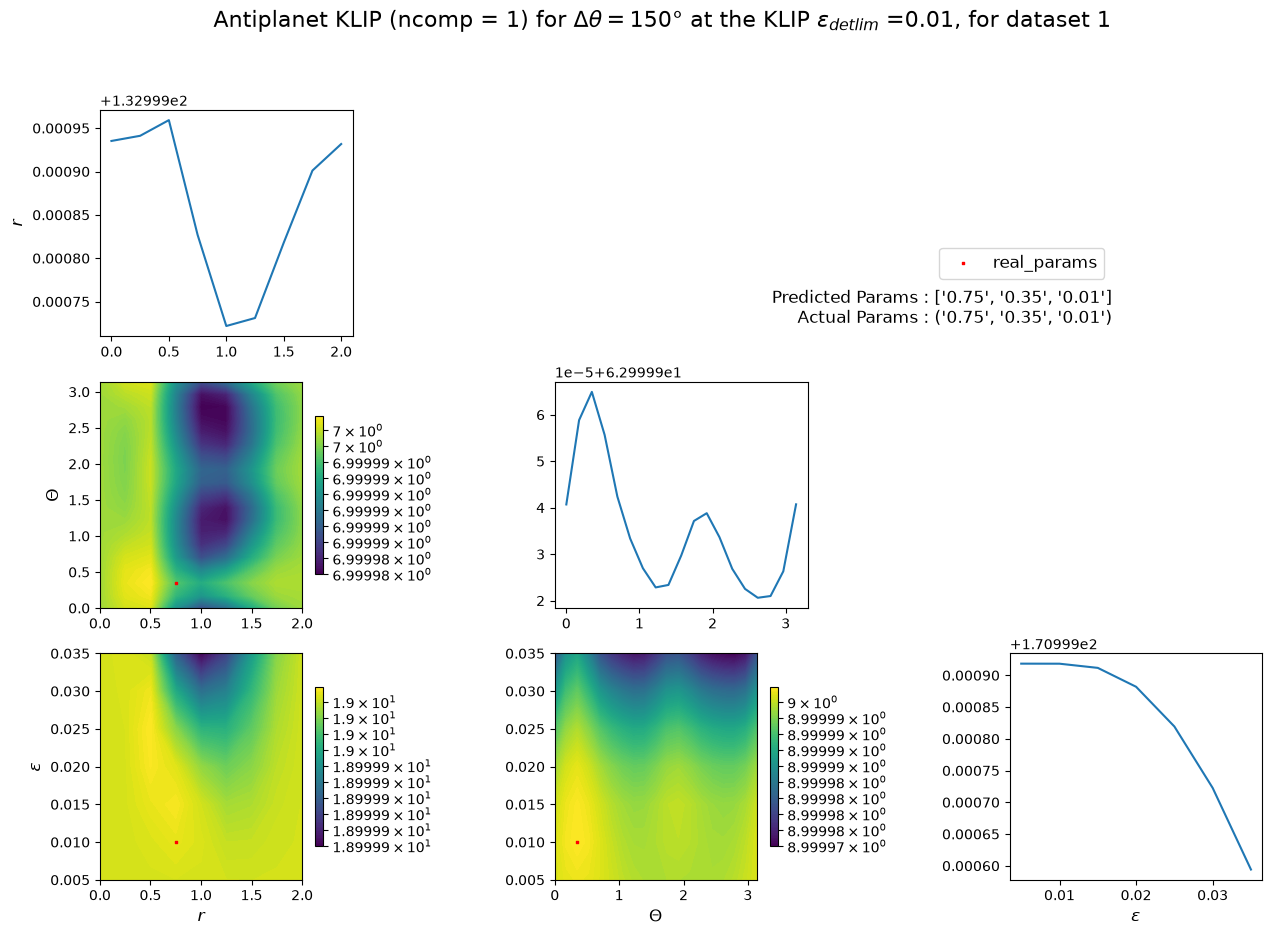

In [94]:
# Code to perform localization using the Antiplanet KLIP Subtraction method for a dataset with 150 degrees of sky coverage angle, a separation of 0.75, a theta of pi/9, and a flux ratio of 0.01 (the KLIP Subtraction detection limit for 150 degree sky coverage). 

KLIP_detlim_test_FRS_150 = np.array([0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035])
cost_pln_KLIP_detlim_anti_KLIP_150_ncomp1, optim_costs_KLIP_detlim_anti_KLIP_150_ncomp1, min_costs_KLIP_detlim_anti_KLIP_150_ncomp1 , min_antiKLIP_KLIP_150_ncomp1= localization_arrays(data_theta = np.pi/9, data_fr = 0.01, test_FRs = KLIP_detlim_test_FRS_150,
                     method = "klip_antiplanet"  , coverage = 150,
                        data_sep = 0.75, test_seps = np.arange(0,2.25,0.25), 
                        test_thetas = test_thetas, 
                        big_dataset = pln_psfs_star_errs_wide_mc_ez[1][np.newaxis, :],  verbose = False)

corner_plots(cost_pln_KLIP_detlim_anti_KLIP_150_ncomp1,  0.01, 150, np.arange(0,2.25,0.25),
    test_thetas, KLIP_detlim_test_FRS_150, "Antiplanet KLIP (ncomp = 1)", "KLIP", (0.75, np.pi/9, 0.01),
    pred_mins = True, pred_mins_avgd= min_antiKLIP_KLIP_150_ncomp1[0], data_id = 0, dataset_id_title=1)

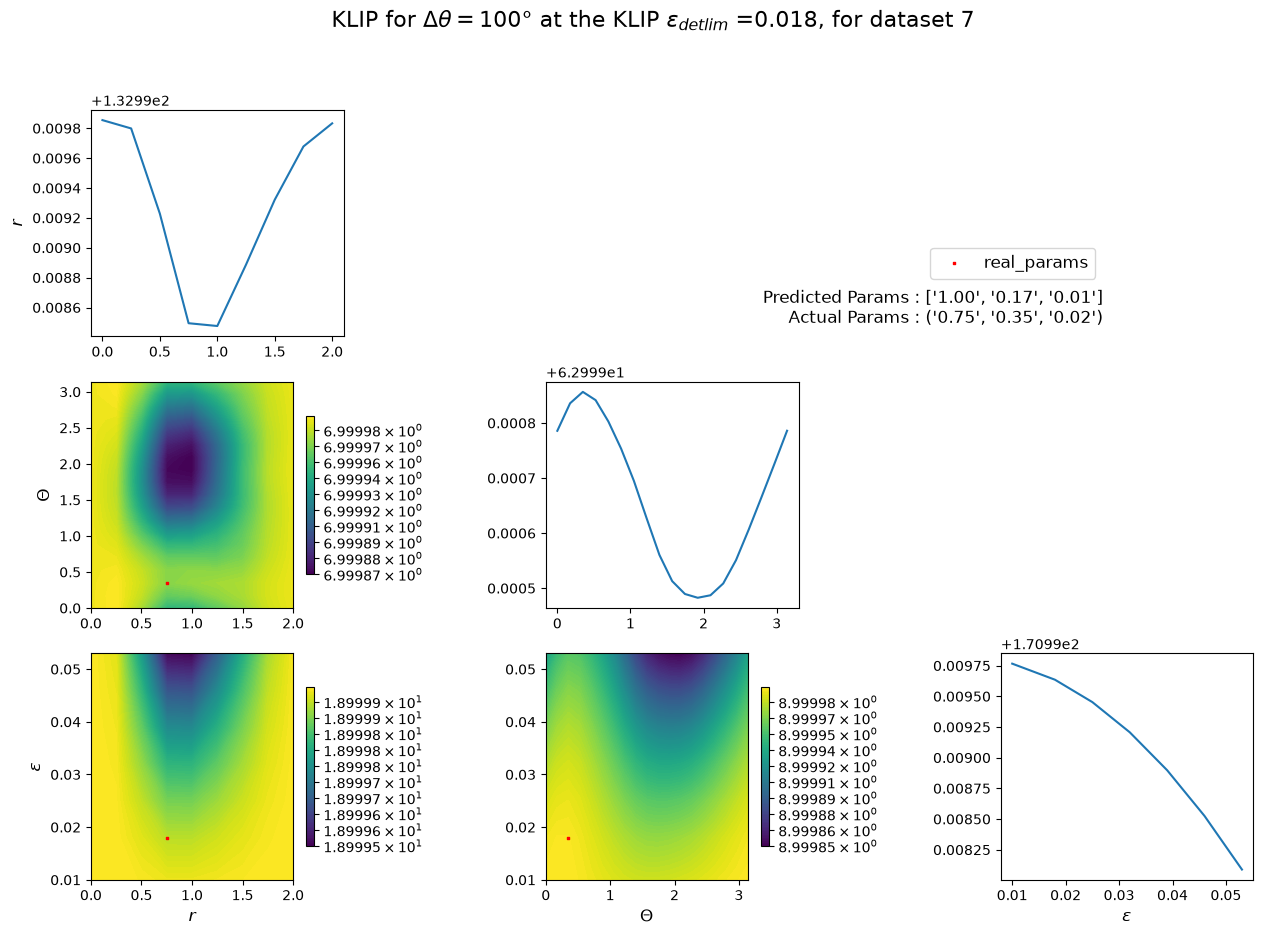

In [ ]:
# Code to perform localization using the KLIP Subtraction method for a dataset with 100 degrees of sky coverage angle, a separation of 0.75, a theta of pi/9, and a flux ratio of 0.019 (the KLIP Subtraction detection limit for 100 degree sky coverage). 

cost_pln_KLIP_detlim_KLIP_100, optim_costs_KLIP_detlim_KLIP_100, min_costs_KLIP_detlim_KLIP_100, min_KLIP_KLIP_100 = localization_arrays(data_theta = np.pi/9, data_fr = 0.018, test_FRs = KLIP_detlim_test_FRS_100,
                     method = "klip"  , coverage = 100,
                        data_sep = 0.75, test_seps = np.arange(0,2.25,0.25), 
                        test_thetas = np.linspace(0,np.pi, 19, endpoint=True), 
                        big_dataset = pln_psfs_star_errs_100_mc_ez[7][np.newaxis, :],  verbose = False)

corner_plots(cost_pln_KLIP_detlim_KLIP_100,  0.018, 100, np.arange(0,2.25,0.25),
    test_thetas, KLIP_detlim_test_FRS_100, "KLIP", "KLIP", (0.75, np.pi/9, 0.018),
    pred_mins = True, pred_mins_avgd= min_KLIP_KLIP_100[0], data_id = 0, dataset_id_title=7)